##### preparation

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product as iproduct


# Statistical modeling
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Sklearn - preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Sklearn - model selection
from sklearn.model_selection import train_test_split, KFold

# Sklearn - metrics
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ NumPy version: {np.__version__}")

✓ All libraries imported successfully!
✓ Pandas version: 2.3.3
✓ NumPy version: 2.4.1


In [3]:
# Load data
file_path = 'busines_opportunities_clean.csv'  # Assumes file is in same folder as notebook

try:
    df = pd.read_csv(file_path)
    print("✓ Data loaded successfully!")
    print(f"✓ Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print("ERROR: File not found!")
    print(f"Looking for: {file_path}")
    print("\nFIX: Update the file_path variable above with the correct location")

✓ Data loaded successfully!
✓ Dataset shape: 9,743 rows × 16 columns


#### Part 1
##### How is the company performing in each of the three software types? 

In [4]:
df = pd.read_csv("busines_opportunities_clean.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())

(9743, 16)
['product_type', 'firm_size', 'firm_platform', 'account_team_rank', 'industry_type', 'procurement_locus', 'tech_savvy', 'industry_position', 'deal_size', 'meeting_count', 'internal_champion_score', 'bargaining_power_score', 'geography', 'ceo_education', 'firm_age_years', 'outcome']
  product_type firm_size firm_platform account_team_rank  \
0          ERP     small        Oracle           average   
1          CRM     small           SAP           average   
2          CRM    medium           SAP               low   
3          ERP     large           IBM           average   
4          ERP     large           IBM           average   

               industry_type procurement_locus tech_savvy industry_position  \
0                       tech       centralized    unknown            leader   
1                 automotive       centralized    unknown          follower   
2                       tech        LOB_driven    unknown          follower   
3  traditional_manufacturing 

In [5]:
print("product_type:", df['product_type'].unique())
print("geography:", df['geography'].unique())
print("outcome:", df['outcome'].unique())
print("\noutcome分布:\n", df['outcome'].value_counts())
df['sale'] = (df['outcome'] == 'SALE').astype(int)
baseline = df['sale'].mean() * 100

print(f"\nBaseline win rate: {baseline:.2f}%")

product_type: ['ERP' 'CRM' 'DSC']
geography: ['ROW' 'Europe' 'US']
outcome: ['NO SALE' 'SALE']

outcome分布:
 outcome
NO SALE    8752
SALE        991
Name: count, dtype: int64

Baseline win rate: 10.17%


In [6]:
# 各产品类型的成交率
product_performance = df.groupby('product_type').apply(
    lambda x: pd.Series({
        'Total': len(x),
        'Sales': (x['outcome'] == 'SALE').sum(),
        'Win_Rate': (x['outcome'] == 'SALE').mean() * 100
    })
).round(2)

print("=== Performance by Product Type ===")
print(product_performance)

=== Performance by Product Type ===
               Total  Sales  Win_Rate
product_type                         
CRM           4116.0  461.0     11.20
DSC           1912.0  201.0     10.51
ERP           3715.0  329.0      8.86


##### How is the company performing in different markets? 

In [7]:
# 各市场的成交率
market_performance = df.groupby('geography').apply(
    lambda x: pd.Series({
        'Total': len(x),
        'Sales': (x['outcome'] == 'SALE').sum(),
        'Win_Rate': (x['outcome'] == 'SALE').mean() * 100
    })
).round(2)

print("=== Performance by Market ===")
print(market_performance)


=== Performance by Market ===
            Total  Sales  Win_Rate
geography                         
Europe     3746.0  319.0      8.52
ROW        2453.0  268.0     10.93
US         3544.0  404.0     11.40


##### What is driving this performance?  

In [8]:
## numerical data
# 把outcome转成0/1
df['sale'] = (df['outcome'] == 'SALE').astype(int)

# 成交 vs 未成交的数值变量均值对比
num_cols = ['deal_size', 'meeting_count', 'internal_champion_score', 'bargaining_power_score', 'firm_age_years']

comparison = df.groupby('outcome')[num_cols].mean().round(2)
print("=== Numerical Variables: SALE vs NO SALE ===")
print(comparison)

=== Numerical Variables: SALE vs NO SALE ===
         deal_size  meeting_count  internal_champion_score  \
outcome                                                      
NO SALE   79560.21           2.29                     3.22   
SALE      79511.46           2.10                     3.58   

         bargaining_power_score  firm_age_years  
outcome                                          
NO SALE                    3.53           23.63  
SALE                       3.52           24.02  


In [9]:
# catagorical data 
cat_cols = ['firm_size', 'account_team_rank', 'industry_type', 
            'procurement_locus', 'tech_savvy', 'industry_position', 
            'ceo_education']

for col in cat_cols:
    win_rate = df.groupby(col)['sale'].mean() * 100
    print(f"\n=== {col} ===")
    print(win_rate.round(2).sort_values(ascending=False))


=== firm_size ===
firm_size
medium    10.33
large     10.13
small      9.96
Name: sale, dtype: float64

=== account_team_rank ===
account_team_rank
high       15.49
average     9.65
low         4.98
Name: sale, dtype: float64

=== industry_type ===
industry_type
automotive                   10.67
tech                         10.64
traditional_manufacturing    10.12
healthcare                    8.81
Name: sale, dtype: float64

=== procurement_locus ===
procurement_locus
LOB_driven            11.25
centralized            9.95
procurement_driven     8.97
Name: sale, dtype: float64

=== tech_savvy ===
tech_savvy
tech_savvy    12.32
naive         10.25
unknown        9.25
Name: sale, dtype: float64

=== industry_position ===
industry_position
leader      10.70
follower     9.89
Name: sale, dtype: float64

=== ceo_education ===
ceo_education
high_school        11.03
other_graduate     10.56
mba                10.26
bsc                 9.95
some_university     9.95
Name: sale, dtype: float6

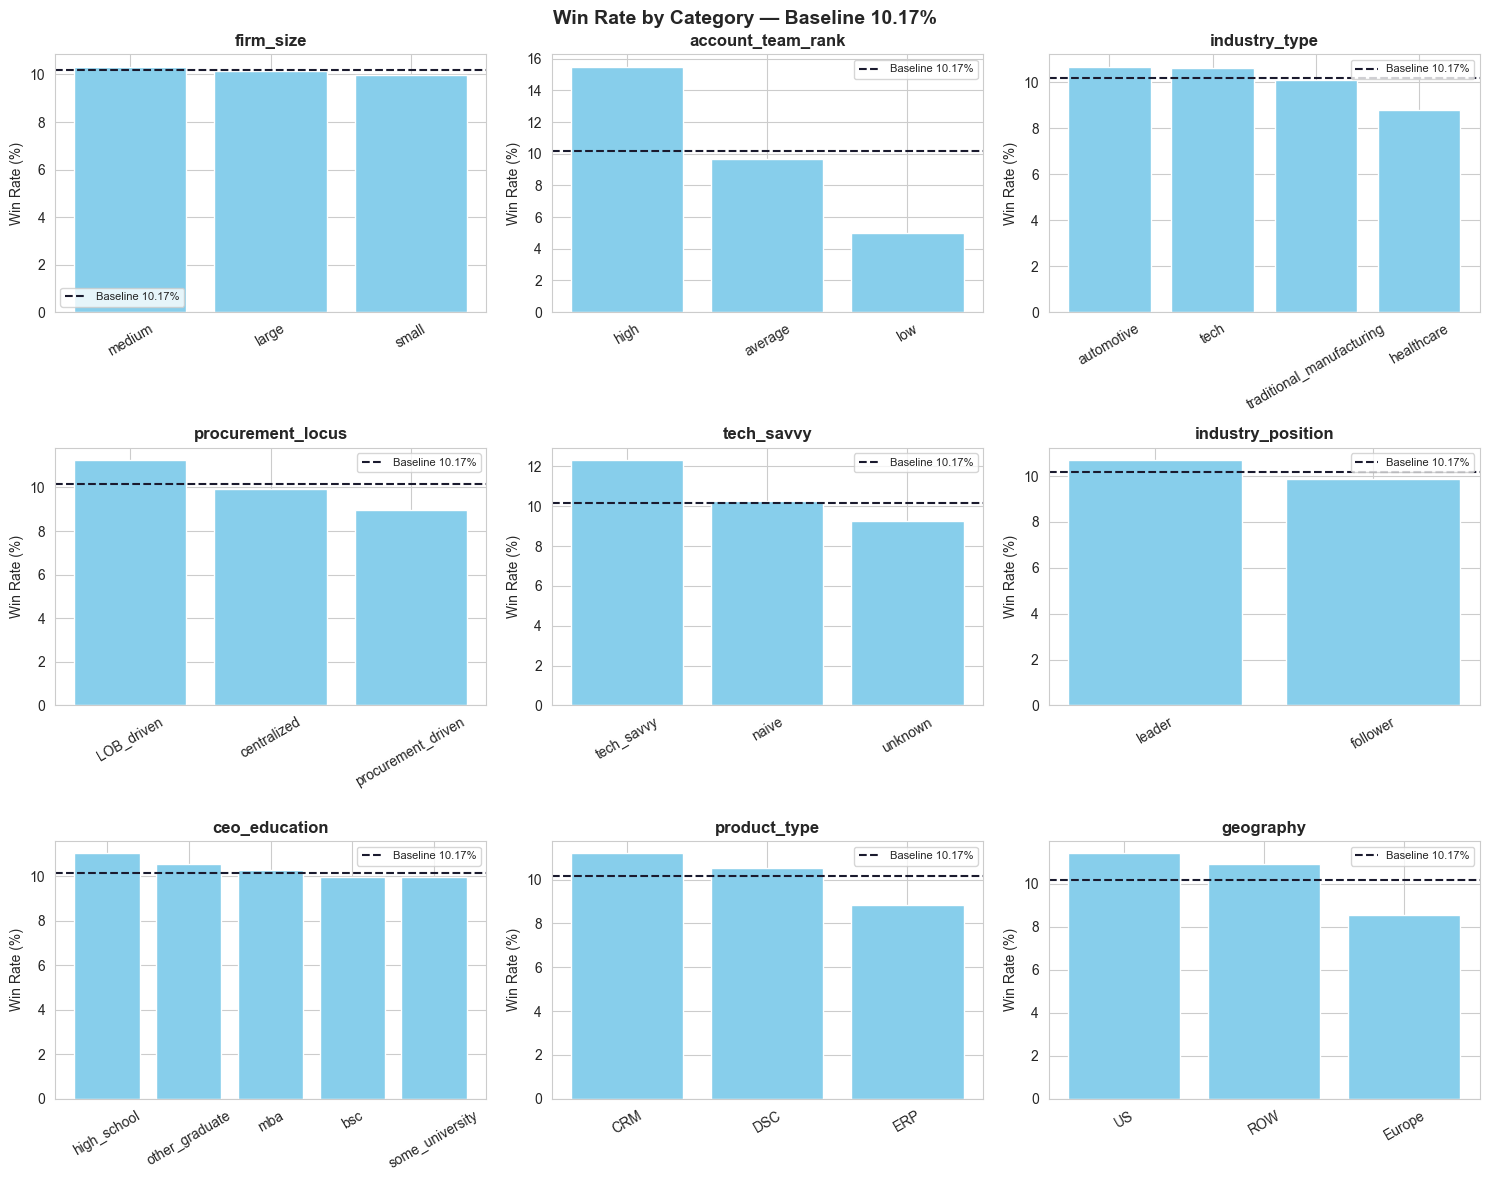

In [10]:
#可视化
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

cat_cols = ['firm_size', 'account_team_rank', 'industry_type',
            'procurement_locus', 'tech_savvy', 'industry_position',
            'ceo_education', 'product_type', 'geography']

for i, col in enumerate(cat_cols):
    win_rate = df.groupby(col)['sale'].mean() * 100
    win_rate = win_rate.sort_values(ascending=False)
    
    axes[i].bar(win_rate.index, win_rate.values, color='#87CEEB', edgecolor='white')
    axes[i].axhline(y=10.17, color='#1a1a2e', linestyle='--', linewidth=1.5, label='Baseline 10.17%')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Win Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

plt.suptitle('Win Rate by Category — Baseline 10.17%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Part 2 

##### logistic regression

In [11]:
# 定义 X 和 y（包含所有特征：类别 + 数值）
drop_cols   = ['outcome', 'sale']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df['sale'].copy()

# 识别类别列和数值列
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print("X shape:", X.shape)
print("\nCategorical:", cat_cols)
print("Numerical:  ", num_cols)
print("\ny 分布:\n", y.value_counts())

X shape: (9743, 15)

Categorical: ['product_type', 'firm_size', 'firm_platform', 'account_team_rank', 'industry_type', 'procurement_locus', 'tech_savvy', 'industry_position', 'geography', 'ceo_education']
Numerical:   ['deal_size', 'meeting_count', 'internal_champion_score', 'bargaining_power_score', 'firm_age_years']

y 分布:
 sale
0    8752
1     991
Name: count, dtype: int64


In [12]:
# ===== Train / Val / Test split（先 split，再做特征筛选）=====
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# ===== 预处理（类别 OHE + 数值 StandardScaler）=====
from sklearn.preprocessing import StandardScaler

preprocess = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# ===== 评估函数 =====
def evaluate_classifier(pipe, X, y, name="Model"):
    pred  = pipe.predict(X)
    proba = pipe.predict_proba(X)[:, 1]
    print(f"=== {name} ===")
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("ROC-AUC:",  round(roc_auc_score(y, proba), 4))
    print("\nConfusion matrix:\n", confusion_matrix(y, pred))
    print("\nClassification report:\n",
          classification_report(y, pred, target_names=['NO SALE', 'SALE']))

Train: (5480, 15) Val: (1827, 15) Test: (2436, 15)


In [13]:
# Elastic Net 参数搜索（只用 X_train，避免 data leakage）
cv = KFold(n_splits=5, shuffle=True, random_state=42)

C_values  = [0.001, 0.01, 0.1, 1.0, 10.0]
l1_ratios = [0, 0.2, 0.5, 0.8, 1]

results = []

for C in C_values:
    for ratio in l1_ratios:
        auc_scores = []

        for train_idx, test_idx in cv.split(X_train):
            pipe = Pipeline([
                ('prep', preprocess),
                ('model', LogisticRegression(
                    penalty='elasticnet',
                    C=C,
                    l1_ratio=ratio,
                    solver='saga',
                    max_iter=1000,
                    class_weight='balanced'   # 修复：加上 class_weight
                ))
            ])
            pipe.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
            proba = pipe.predict_proba(X_train.iloc[test_idx])[:, 1]
            auc_scores.append(roc_auc_score(y_train.iloc[test_idx], proba))

        results.append({
            'C'       : C,
            'l1_ratio': ratio,
            'AUC'     : round(np.mean(auc_scores), 4)
        })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print(results_df.to_string(index=False))
print(f"\n最优参数:")
print(results_df.iloc[0])

     C  l1_ratio    AUC
 0.100       1.0 0.6234
 0.100       0.8 0.6231
 0.010       0.0 0.6228
 0.100       0.5 0.6227
 0.010       0.2 0.6226
 0.100       0.2 0.6220
 0.100       0.0 0.6216
 1.000       0.8 0.6215
 1.000       1.0 0.6215
 1.000       0.5 0.6214
 1.000       0.0 0.6213
 1.000       0.2 0.6213
10.000       0.2 0.6212
10.000       0.8 0.6212
10.000       0.5 0.6212
10.000       1.0 0.6212
10.000       0.0 0.6212
 0.001       0.0 0.6185
 0.010       0.5 0.6087
 0.010       0.8 0.5931
 0.010       1.0 0.5903
 0.001       0.2 0.5824
 0.001       0.8 0.5000
 0.001       1.0 0.5000
 0.001       0.5 0.5000

最优参数:
C           0.1000
l1_ratio    1.0000
AUC         0.6234
Name: 14, dtype: float64


保留变量数: 25 / 37
                                         Feature  Coefficient
11                    cat__account_team_rank_low    -0.496615
6                         cat__firm_platform_IBM     0.327216
13                 cat__industry_type_healthcare    -0.317363
20                    cat__tech_savvy_tech_savvy     0.282647
10                   cat__account_team_rank_high     0.282346
24                         cat__geography_Europe    -0.231615
31            cat__ceo_education_some_university    -0.201036
33                            num__meeting_count    -0.197838
16             cat__procurement_locus_LOB_driven     0.193354
34                  num__internal_champion_score     0.189179
21                       cat__tech_savvy_unknown    -0.119691
28                cat__ceo_education_high_school     0.080158
36                           num__firm_age_years     0.067900
1                          cat__product_type_DSC     0.049885
2                          cat__product_type_ERP    -0.

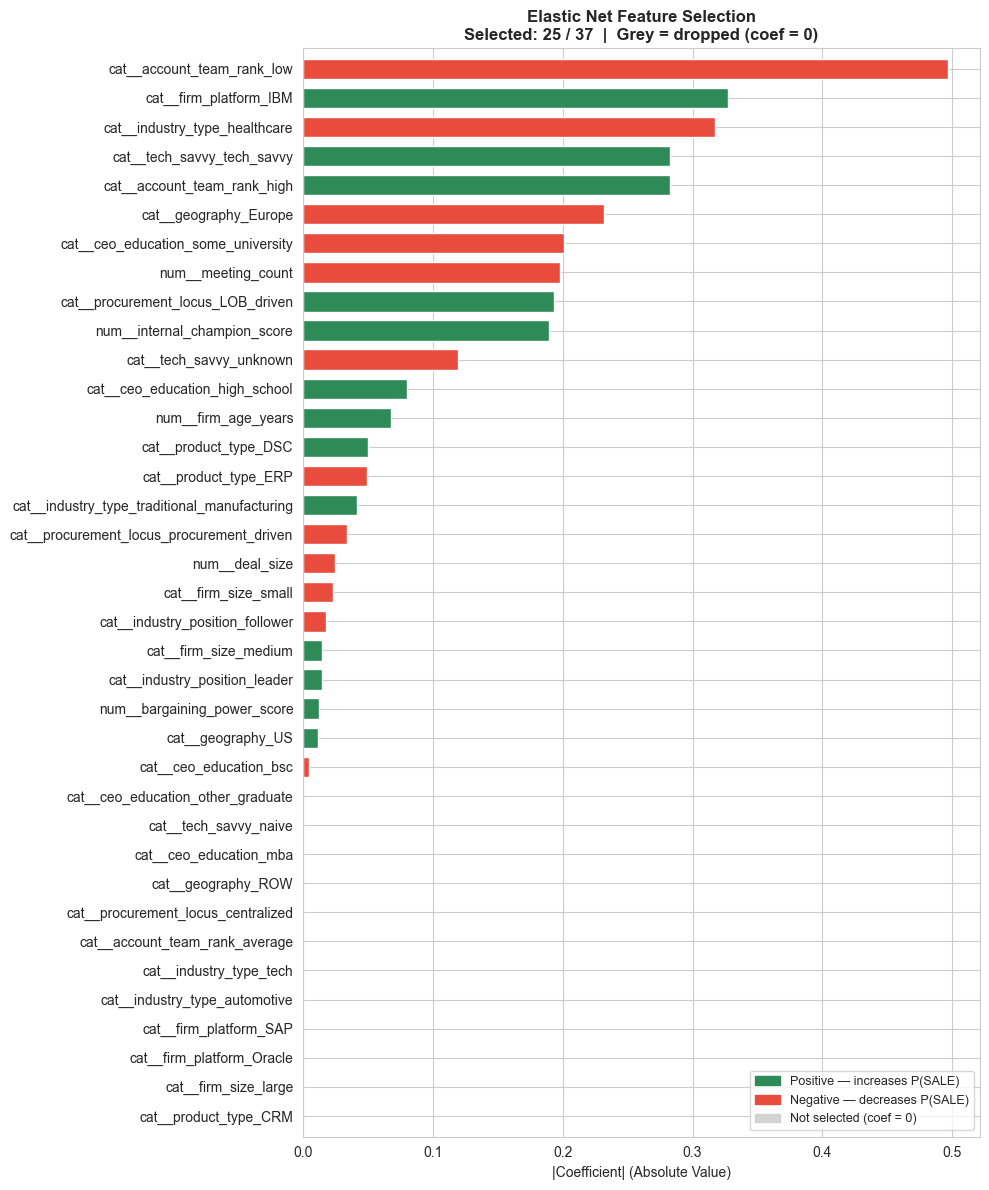

In [14]:
# 用最优参数在 X_train 上 fit Elastic Net，提取选出的变量
elasticnet = LogisticRegression(
    penalty='elasticnet',
    C=0.1,
    l1_ratio=1,
    solver='saga',
    max_iter=1000,
    class_weight='balanced'
)

pipe_en = Pipeline([('prep', preprocess), ('model', elasticnet)])
pipe_en.fit(X_train, y_train)   # 只用 X_train！

# 查看保留的变量
feature_names = pipe_en['prep'].get_feature_names_out()
coefs         = pipe_en['model'].coef_[0]

selected = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefs
})

selected = selected[selected['Coefficient'] != 0].sort_values(
    'Coefficient', key=abs, ascending=False)

print(f"保留变量数: {len(selected)} / {len(feature_names)}")
print(selected)

# 可视化：系数绝对值为长度，颜色代表正负
all_feat_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefs
}).sort_values('Coefficient', key=abs, ascending=True)  # 升序，最强在上

bar_colors = []
for val in all_feat_df['Coefficient']:
    if val == 0:
        bar_colors.append('#D3D3D3')   # 灰：未选中
    elif val > 0:
        bar_colors.append('#2E8B57')   # 绿：正系数
    else:
        bar_colors.append('#E74C3C')   # 红：负系数

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(all_feat_df['Feature'],
        all_feat_df['Coefficient'].abs(),   # 高度取绝对值
        color=bar_colors, edgecolor='white', height=0.7)

ax.set_xlabel('|Coefficient| (Absolute Value)')
ax.set_title(f'Elastic Net Feature Selection\n'
             f'Selected: {len(selected)} / {len(feature_names)}  |  '
             f'Grey = dropped (coef = 0)',
             fontweight='bold', fontsize=12)

from matplotlib.patches import Patch
legend = [
    Patch(color='#2E8B57', label='Positive — increases P(SALE)'),
    Patch(color='#E74C3C', label='Negative — decreases P(SALE)'),
    Patch(color='#D3D3D3', label='Not selected (coef = 0)'),
]

ax.margins(y=0.01) 
ax.legend(handles=legend, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()


In [15]:
# 自动提取选出的原始列名（兼容类别变量和数值变量）
selected_original_cols = []

for col in X.columns.tolist():
    for feat in selected['Feature']:
        # 类别变量：cat__col_value
        if feat.startswith(f'cat__{col}_') or feat == f'cat__{col}':
            if col not in selected_original_cols:
                selected_original_cols.append(col)
            break
        # 数值变量：num__col
        if feat == f'num__{col}':
            if col not in selected_original_cols:
                selected_original_cols.append(col)
            break

print(f"选出的原始列数: {len(selected_original_cols)}")
print("\n类别变量:", [c for c in selected_original_cols if c in cat_cols])
print("数值变量:", [c for c in selected_original_cols if c in num_cols])
print("\n全部:", selected_original_cols)

选出的原始列数: 15

类别变量: ['product_type', 'firm_size', 'firm_platform', 'account_team_rank', 'industry_type', 'procurement_locus', 'tech_savvy', 'industry_position', 'geography', 'ceo_education']
数值变量: ['deal_size', 'meeting_count', 'internal_champion_score', 'bargaining_power_score', 'firm_age_years']

全部: ['product_type', 'firm_size', 'firm_platform', 'account_team_rank', 'industry_type', 'procurement_locus', 'tech_savvy', 'industry_position', 'deal_size', 'meeting_count', 'internal_champion_score', 'bargaining_power_score', 'geography', 'ceo_education', 'firm_age_years']


In [16]:
# 用筛选出的变量切出 train/val/test（不重新 split！）
X_train_sel = X_train[selected_original_cols].copy()
X_val_sel   = X_val[selected_original_cols].copy()
X_test_sel  = X_test[selected_original_cols].copy()

# 重新定义预处理（只针对选出的变量）
cat_sel = [c for c in selected_original_cols if c in cat_cols]
num_sel = [c for c in selected_original_cols if c in num_cols]

transformers = [('cat', OneHotEncoder(handle_unknown='ignore'), cat_sel)]
if num_sel:
    transformers.append(('num', StandardScaler(), num_sel))

preprocess_selected = ColumnTransformer(transformers=transformers)

print("Train:", X_train_sel.shape)
print("Val:  ", X_val_sel.shape)
print("Test: ", X_test_sel.shape)
print("\n类别变量:", cat_sel)
print("数值变量:", num_sel)

Train: (5480, 15)
Val:   (1827, 15)
Test:  (2436, 15)

类别变量: ['product_type', 'firm_size', 'firm_platform', 'account_team_rank', 'industry_type', 'procurement_locus', 'tech_savvy', 'industry_position', 'geography', 'ceo_education']
数值变量: ['deal_size', 'meeting_count', 'internal_champion_score', 'bargaining_power_score', 'firm_age_years']


In [17]:
# 训练 Logistic Regression on X_train_sel，评估 on X_val_sel
pipe_lr = Pipeline([
    ('prep', preprocess_selected),
    ('model', LogisticRegression(
        penalty='l1',
        C=0.1,
        solver='liblinear',
        max_iter=1000,
        class_weight='balanced'
    ))
])

pipe_lr.fit(X_train_sel, y_train)
print("Logistic Regression 训练完成！\n")

evaluate_classifier(pipe_lr, X_train_sel, y_train, name="Logistic Regression (TRAIN)")
print()
evaluate_classifier(pipe_lr, X_val_sel, y_val, name="Logistic Regression (VAL)")


Logistic Regression 训练完成！

=== Logistic Regression (TRAIN) ===
Accuracy: 0.5861
ROC-AUC: 0.6465

Confusion matrix:
 [[2861 2062]
 [ 206  351]]

Classification report:
               precision    recall  f1-score   support

     NO SALE       0.93      0.58      0.72      4923
        SALE       0.15      0.63      0.24       557

    accuracy                           0.59      5480
   macro avg       0.54      0.61      0.48      5480
weighted avg       0.85      0.59      0.67      5480


=== Logistic Regression (VAL) ===
Accuracy: 0.5928
ROC-AUC: 0.6522

Confusion matrix:
 [[965 676]
 [ 68 118]]

Classification report:
               precision    recall  f1-score   support

     NO SALE       0.93      0.59      0.72      1641
        SALE       0.15      0.63      0.24       186

    accuracy                           0.59      1827
   macro avg       0.54      0.61      0.48      1827
weighted avg       0.85      0.59      0.67      1827



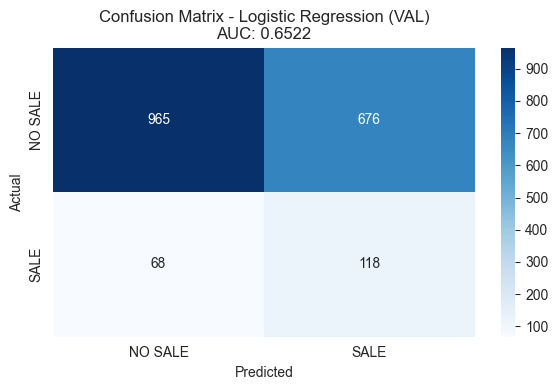

In [18]:
# Confusion Matrix - Logistic Regression (VAL)
y_pred_lr  = pipe_lr.predict(X_val_sel)
y_proba_lr = pipe_lr.predict_proba(X_val_sel)[:, 1]

cm = confusion_matrix(y_val, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO SALE', 'SALE'],
            yticklabels=['NO SALE', 'SALE'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Logistic Regression (VAL)\nAUC: {roc_auc_score(y_val, y_proba_lr):.4f}')
plt.tight_layout()
plt.show()


##### Randon Forest

In [19]:
def evaluate_classifier(pipe, X, y, name="Model"):
    pred  = pipe.predict(X)
    proba = pipe.predict_proba(X)[:, 1]

    print(f"=== {name} ===")
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y, proba), 4))
    print("\nConfusion matrix:\n", confusion_matrix(y, pred))
    print("\nClassification report:\n", classification_report(y, pred, target_names=['NO SALE', 'SALE']))

In [20]:
# --- MANUAL TUNING: 改这些参数然后重新运行 ---
pipe_rf = Pipeline([
    ('prep', preprocess_selected),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf.fit(X_train_sel, y_train)

evaluate_classifier(pipe_rf, X_val_sel, y_val, name="Random Forest (VAL)")

=== Random Forest (VAL) ===
Accuracy: 0.8987
ROC-AUC: 0.6289

Confusion matrix:
 [[1640    1]
 [ 184    2]]

Classification report:
               precision    recall  f1-score   support

     NO SALE       0.90      1.00      0.95      1641
        SALE       0.67      0.01      0.02       186

    accuracy                           0.90      1827
   macro avg       0.78      0.51      0.48      1827
weighted avg       0.88      0.90      0.85      1827



In [21]:
from itertools import product

# 所有参数组合
n_estimators_list = [100, 300, 500]
max_depth_list    = [3, 5, 10, 15, None]
min_leaf_list     = [1, 2, 5, 10]

results_rf = []

for n_est, depth, leaf in product(n_estimators_list, max_depth_list, min_leaf_list):
    pipe = Pipeline([
        ('prep', preprocess_selected),
        ('model', RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            min_samples_leaf=leaf,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
    pipe.fit(X_train_sel, y_train)
    proba = pipe.predict_proba(X_val_sel)[:, 1]
    auc = roc_auc_score(y_val, proba)
    
    results_rf.append({
        'n_estimators'   : n_est,
        'max_depth'      : depth,
        'min_samples_leaf': leaf,
        'AUC'            : round(auc, 4)
    })

results_rf_df = pd.DataFrame(results_rf).sort_values('AUC', ascending=False)
print(results_rf_df.head(10).to_string(index=False))
print(f"\n最优参数:")
print(results_rf_df.iloc[0])

 n_estimators  max_depth  min_samples_leaf    AUC
          100        3.0                 2 0.6738
          100        3.0                 1 0.6733
          100        3.0                 5 0.6731
          100        3.0                10 0.6730
          100        5.0                 2 0.6703
          300        3.0                 2 0.6703
          300        3.0                 5 0.6702
          300        3.0                10 0.6702
          300        3.0                 1 0.6701
          100        5.0                 5 0.6697

最优参数:
n_estimators        100.0000
max_depth             3.0000
min_samples_leaf      2.0000
AUC                   0.6738
Name: 1, dtype: float64


In [22]:
# --- MANUAL TUNING: 改这些参数然后重新运行 ---
pipe_rf = Pipeline([
    ('prep', preprocess_selected),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=3,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf.fit(X_train_sel, y_train)

evaluate_classifier(pipe_rf, X_val_sel, y_val, name="Random Forest (VAL)")

=== Random Forest (VAL) ===
Accuracy: 0.5769
ROC-AUC: 0.6738

Confusion matrix:
 [[931 710]
 [ 63 123]]

Classification report:
               precision    recall  f1-score   support

     NO SALE       0.94      0.57      0.71      1641
        SALE       0.15      0.66      0.24       186

    accuracy                           0.58      1827
   macro avg       0.54      0.61      0.47      1827
weighted avg       0.86      0.58      0.66      1827



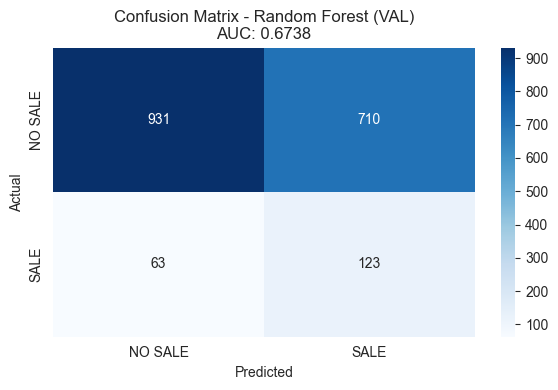

In [23]:
import seaborn as sns

# 预测
y_pred  = pipe_rf.predict(X_val_sel)
y_proba = pipe_rf.predict_proba(X_val_sel)[:, 1]

# Confusion Matrix 可视化
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO SALE', 'SALE'],
            yticklabels=['NO SALE', 'SALE'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Random Forest (VAL)\nAUC: {roc_auc_score(y_val, y_proba):.4f}')
plt.tight_layout()
plt.show()

##### SVM

=== SVM Best (VAL) ===
Accuracy: 0.7833
ROC-AUC: 0.5879

Confusion matrix:
 [[1387  254]
 [ 142   44]]

Classification report:
               precision    recall  f1-score   support

     NO SALE       0.91      0.85      0.88      1641
        SALE       0.15      0.24      0.18       186

    accuracy                           0.78      1827
   macro avg       0.53      0.54      0.53      1827
weighted avg       0.83      0.78      0.80      1827



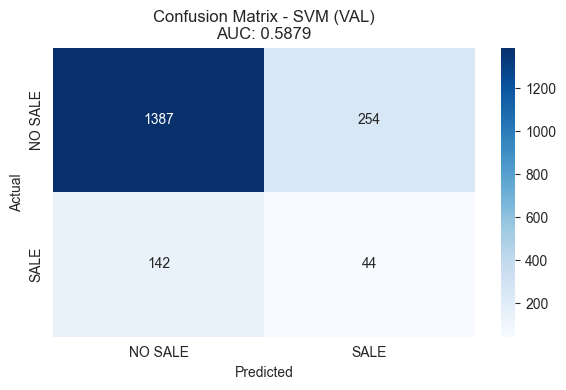

In [24]:
# 用最优参数训练 SVM（从下面 grid search 结果填入）
pipe_svm_best = Pipeline([
    ('prep', preprocess_selected),
    ('model', SVC(
        kernel='rbf',    # ← 从 grid search 结果填
        C=5,             # ← 从 grid search 结果填
        gamma='scale',   # ← 从 grid search 结果填
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

pipe_svm_best.fit(X_train_sel, y_train)
evaluate_classifier(pipe_svm_best, X_val_sel, y_val, name="SVM Best (VAL)")

# Confusion Matrix
y_pred_svm  = pipe_svm_best.predict(X_val_sel)
y_proba_svm = pipe_svm_best.predict_proba(X_val_sel)[:, 1]

cm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO SALE', 'SALE'],
            yticklabels=['NO SALE', 'SALE'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - SVM (VAL)\nAUC: {roc_auc_score(y_val, y_proba_svm):.4f}')
plt.tight_layout()
plt.show()

In [25]:
# SVM Grid Search
C_list      = [0.1, 1, 5, 10]
kernel_list = ['rbf', 'linear']
gamma_list  = ['scale', 0.01, 0.1]

results_svm = []

for k in kernel_list:
    for c in C_list:
        gammas = gamma_list if k == 'rbf' else ['scale']
        for g in gammas:
            pipe = Pipeline([
                ('prep', preprocess_selected),
                ('model', SVC(
                    kernel=k, C=c, gamma=g,
                    class_weight='balanced',
                    probability=True,
                    random_state=42
                ))
            ])
            pipe.fit(X_train_sel, y_train)
            proba = pipe.predict_proba(X_val_sel)[:, 1]
            auc = roc_auc_score(y_val, proba)
            results_svm.append({
                'kernel': k, 'C': c, 'gamma': g,
                'AUC': round(auc, 4)
            })

results_svm_df = pd.DataFrame(results_svm).sort_values('AUC', ascending=False)
print(results_svm_df.to_string(index=False))
print(f"\n最优参数:")
print(results_svm_df.iloc[0])

kernel    C gamma    AUC
   rbf  1.0  0.01 0.6672
   rbf  5.0  0.01 0.6670
   rbf 10.0  0.01 0.6595
   rbf  0.1 scale 0.6591
   rbf  0.1   0.1 0.6574
   rbf  0.1  0.01 0.6526
linear  5.0 scale 0.6478
linear  1.0 scale 0.6478
linear  0.1 scale 0.6478
linear 10.0 scale 0.6477
   rbf  1.0 scale 0.6190
   rbf  1.0   0.1 0.6093
   rbf  5.0 scale 0.5879
   rbf  5.0   0.1 0.5876
   rbf 10.0 scale 0.5839
   rbf 10.0   0.1 0.5802

最优参数:
kernel       rbf
C            1.0
gamma       0.01
AUC       0.6672
Name: 4, dtype: object


=== SVM Best (VAL) ===
Accuracy: 0.5731
ROC-AUC: 0.6672

Confusion matrix:
 [[919 722]
 [ 58 128]]

Classification report:
               precision    recall  f1-score   support

     NO SALE       0.94      0.56      0.70      1641
        SALE       0.15      0.69      0.25       186

    accuracy                           0.57      1827
   macro avg       0.55      0.62      0.47      1827
weighted avg       0.86      0.57      0.66      1827



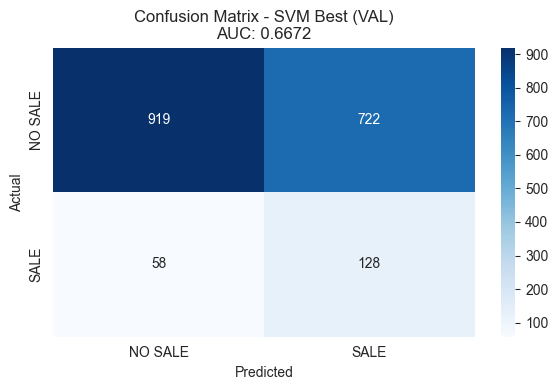

In [26]:
# 最优 SVM
pipe_svm_best = Pipeline([
    ('prep', preprocess_selected),
    ('model', SVC(
        kernel='rbf',
        C=1,
        gamma=0.01,
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

pipe_svm_best.fit(X_train_sel, y_train)
evaluate_classifier(pipe_svm_best, X_val_sel, y_val, name="SVM Best (VAL)")

# Confusion Matrix
y_pred_svm  = pipe_svm_best.predict(X_val_sel)
y_proba_svm = pipe_svm_best.predict_proba(X_val_sel)[:, 1]

cm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO SALE', 'SALE'],
            yticklabels=['NO SALE', 'SALE'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - SVM Best (VAL)\nAUC: {roc_auc_score(y_val, y_proba_svm):.4f}')
plt.tight_layout()
plt.show()

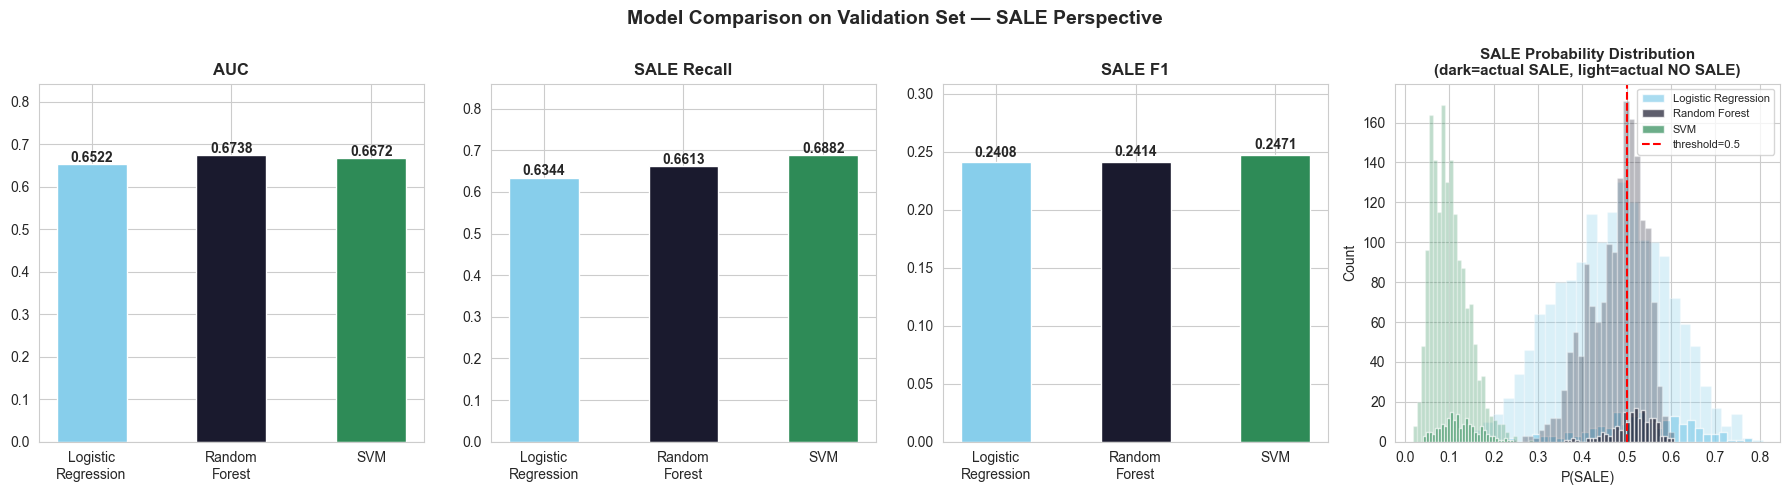

                         AUC  SALE Recall  SALE Precision  SALE F1
Model                                                             
Logistic\nRegression  0.6522       0.6344          0.1486   0.2408
Random\nForest        0.6738       0.6613          0.1477   0.2414
SVM                   0.6672       0.6882          0.1506   0.2471


In [27]:
# ===== 三模型对比 (含 SALE 概率分布) =====
models = {
    'Logistic\nRegression': pipe_lr,
    'Random\nForest':       pipe_rf,
    'SVM':                  pipe_svm_best
}

rows = []
for name, pipe in models.items():
    pred  = pipe.predict(X_val_sel)
    proba = pipe.predict_proba(X_val_sel)[:, 1]   # SALE 概率
    report = classification_report(y_val, pred, target_names=['NO SALE', 'SALE'], output_dict=True)
    rows.append({
        'Model':          name,
        'AUC':            round(roc_auc_score(y_val, proba), 4),
        'SALE Recall':    round(report['SALE']['recall'], 4),
        'SALE Precision': round(report['SALE']['precision'], 4),
        'SALE F1':        round(report['SALE']['f1-score'], 4),
        'proba':          proba
    })

colors = ['#87CEEB', '#1a1a2e', '#2E8B57']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# --- 图1~3: AUC / SALE Recall / SALE F1 ---
for i, metric in enumerate(['AUC', 'SALE Recall', 'SALE F1']):
    values = [r[metric] for r in rows]
    names  = [r['Model'] for r in rows]
    bars   = axes[i].bar(names, values, color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, max(values) * 1.25)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# --- 图4: SALE 概率分布 ---
ax = axes[3]
# 分别画 SALE 和 NO SALE 样本
sale_mask   = y_val == 1
nosale_mask = y_val == 0

for r, color in zip(rows, colors):
    ax.hist(r['proba'][nosale_mask], bins=30, alpha=0.3, color=color)
    ax.hist(r['proba'][sale_mask],   bins=30, alpha=0.7, color=color,
            label=r['Model'].replace('\n', ' '))

ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='threshold=0.5')
ax.set_title('SALE Probability Distribution\n(dark=actual SALE, light=actual NO SALE)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('P(SALE)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

plt.suptitle('Model Comparison on Validation Set — SALE Perspective', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 数字表格
compare_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'proba'} for r in rows])
print(compare_df.set_index('Model').to_string())

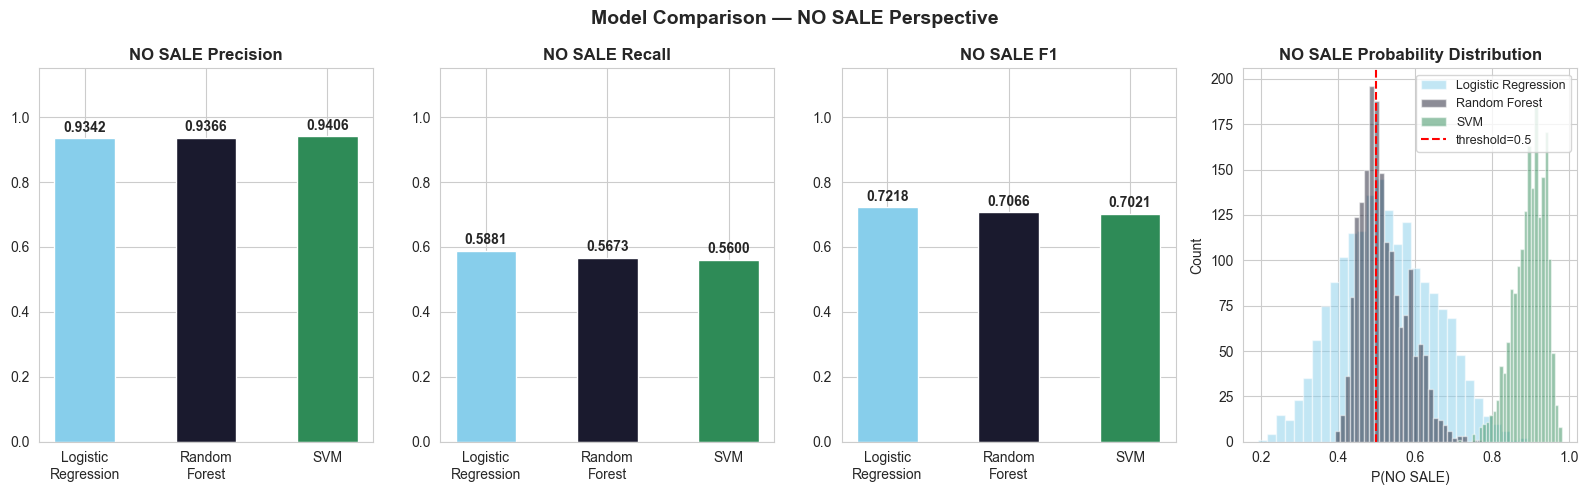

                      NO SALE Precision  NO SALE Recall  NO SALE F1
Model                                                              
Logistic\nRegression             0.9342          0.5881      0.7218
Random\nForest                   0.9366          0.5673      0.7066
SVM                              0.9406          0.5600      0.7021


In [28]:
# ===== 按 NO SALE 性能做模型对比 =====
models = {
    'Logistic\nRegression': pipe_lr,
    'Random\nForest':       pipe_rf,
    'SVM':                  pipe_svm_best
}

rows = []
for name, pipe in models.items():
    pred  = pipe.predict(X_val_sel)
    proba = pipe.predict_proba(X_val_sel)[:, 0]   # NO SALE 概率
    report = classification_report(y_val, pred, target_names=['NO SALE', 'SALE'], output_dict=True)
    rows.append({
        'Model':              name,
        'NO SALE Precision':  round(report['NO SALE']['precision'], 4),
        'NO SALE Recall':     round(report['NO SALE']['recall'], 4),
        'NO SALE F1':         round(report['NO SALE']['f1-score'], 4),
        'proba':              proba
    })

# --- 图1: NO SALE 指标对比 bar chart ---
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics   = ['NO SALE Precision', 'NO SALE Recall', 'NO SALE F1']
colors    = ['#87CEEB', '#1a1a2e', '#2E8B57']

for i, metric in enumerate(metrics):
    values = [r[metric] for r in rows]
    names  = [r['Model'] for r in rows]
    bars   = axes[i].bar(names, values, color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, 1.15)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# --- 图2: NO SALE 概率分布 ---
ax = axes[3]
for r, color in zip(rows, colors):
    ax.hist(r['proba'], bins=30, alpha=0.5, color=color, label=r['Model'].replace('\n', ' '))
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='threshold=0.5')
ax.set_title('NO SALE Probability Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('P(NO SALE)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

plt.suptitle('Model Comparison — NO SALE Perspective', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 打印数字表格
compare_nosale = pd.DataFrame([{k: v for k, v in r.items() if k != 'proba'} for r in rows])
compare_nosale = compare_nosale.set_index('Model')
print(compare_nosale.to_string())

FINAL EVALUATION ON TEST SET (unseen data)
                     Test AUC  Val AUC  SALE Recall  SALE Precision  SALE F1
Model                                                                       
Logistic Regression    0.6399   0.6522       0.6210          0.1422   0.2314
Random Forest          0.6683   0.6738       0.6815          0.1521   0.2487
SVM                    0.6561   0.6672       0.6774          0.1485   0.2437


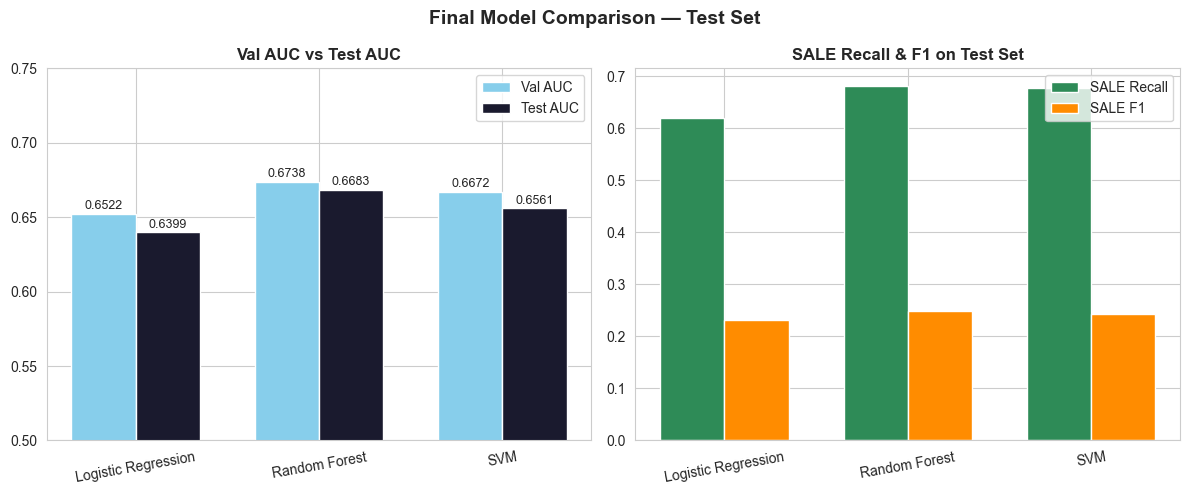

In [29]:
# ===== 最终评估：在 X_test 上报告三个模型的真实性能 =====
# X_test 从未参与过调参，这是最公平的评估

print("=" * 50)
print("FINAL EVALUATION ON TEST SET (unseen data)")
print("=" * 50)

models_final = {
    'Logistic Regression': pipe_lr,
    'Random Forest'      : pipe_rf,
    'SVM'                : pipe_svm_best
}

rows = []
for name, pipe in models_final.items():
    pred  = pipe.predict(X_test_sel)
    proba = pipe.predict_proba(X_test_sel)[:, 1]
    report = classification_report(y_test, pred,
                                   target_names=['NO SALE', 'SALE'],
                                   output_dict=True)
    rows.append({
        'Model'          : name,
        'Test AUC'       : round(roc_auc_score(y_test, proba), 4),
        'Val AUC'        : round(roc_auc_score(y_val, pipe.predict_proba(X_val_sel)[:, 1]), 4),
        'SALE Recall'    : round(report['SALE']['recall'], 4),
        'SALE Precision' : round(report['SALE']['precision'], 4),
        'SALE F1'        : round(report['SALE']['f1-score'], 4),
    })

final_df = pd.DataFrame(rows).set_index('Model')
print(final_df.to_string())

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Val AUC vs Test AUC 对比
x = np.arange(len(rows))
w = 0.35
axes[0].bar(x - w/2, final_df['Val AUC'],  width=w, label='Val AUC',  color='#87CEEB')
axes[0].bar(x + w/2, final_df['Test AUC'], width=w, label='Test AUC', color='#1a1a2e')
axes[0].set_xticks(x)
axes[0].set_xticklabels(final_df.index, rotation=10)
axes[0].set_ylim(0.5, 0.75)
axes[0].set_title('Val AUC vs Test AUC', fontweight='bold')
axes[0].legend()
for i, row in final_df.iterrows():
    idx = list(final_df.index).index(i)
    axes[0].text(idx - w/2, row['Val AUC']  + 0.003, f"{row['Val AUC']:.4f}",  ha='center', fontsize=9)
    axes[0].text(idx + w/2, row['Test AUC'] + 0.003, f"{row['Test AUC']:.4f}", ha='center', fontsize=9)

# SALE Recall / F1 on Test
metrics = ['SALE Recall', 'SALE F1']
colors  = ['#2E8B57', '#FF8C00']
for i, metric in enumerate(metrics):
    axes[1].bar(np.arange(len(rows)) + i*w,
                final_df[metric], width=w, label=metric, color=colors[i])
axes[1].set_xticks(np.arange(len(rows)) + w/2)
axes[1].set_xticklabels(final_df.index, rotation=10)
axes[1].set_title('SALE Recall & F1 on Test Set', fontweight='bold')
axes[1].legend()

plt.suptitle('Final Model Comparison — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [30]:
print(selected_original_cols)
print("\n类别变量:", [c for c in selected_original_cols if c in cat_cols])
print("数值变量:", [c for c in selected_original_cols if c in num_cols])


['product_type', 'firm_size', 'firm_platform', 'account_team_rank', 'industry_type', 'procurement_locus', 'tech_savvy', 'industry_position', 'deal_size', 'meeting_count', 'internal_champion_score', 'bargaining_power_score', 'geography', 'ceo_education', 'firm_age_years']

类别变量: ['product_type', 'firm_size', 'firm_platform', 'account_team_rank', 'industry_type', 'procurement_locus', 'tech_savvy', 'industry_position', 'geography', 'ceo_education']
数值变量: ['deal_size', 'meeting_count', 'internal_champion_score', 'bargaining_power_score', 'firm_age_years']


校准前后对比（Val set 平均预测概率 vs 真实基准 10.2%）：
  LR  uncalibrated: 47.4%
  LR  calibrated:   10.1%
  RF  uncalibrated: 48.2%
  RF  calibrated:   10.2%
  SVM (reference):  10.2%
  True base rate:   10.2%


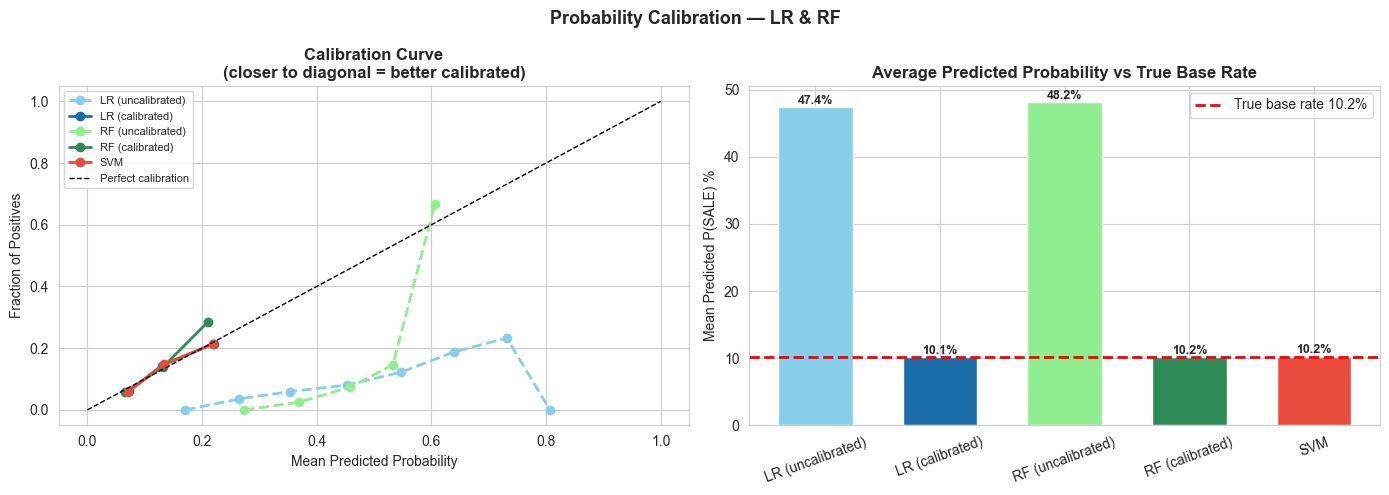

In [31]:
# ===== 校准 LR 和 RF 的概率输出 =====
# 重新定义 base pipeline（未 fit 的）
pipe_lr_base = Pipeline([
    ('prep', preprocess_selected),
    ('model', LogisticRegression(
        penalty='l1', C=0.1, solver='liblinear',
        max_iter=1000, class_weight='balanced'
    ))
])

pipe_rf_base = Pipeline([
    ('prep', preprocess_selected),
    ('model', RandomForestClassifier(
        n_estimators=500, max_depth=3, min_samples_leaf=1,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

# Sigmoid calibration（5-fold 内部交叉验证）
cal_lr = CalibratedClassifierCV(pipe_lr_base, cv=5, method='sigmoid')
cal_rf = CalibratedClassifierCV(pipe_rf_base, cv=5, method='sigmoid')

cal_lr.fit(X_train_sel, y_train)
cal_rf.fit(X_train_sel, y_train)

# ===== 验证校准效果 =====
print("校准前后对比（Val set 平均预测概率 vs 真实基准 10.2%）：")
print(f"  LR  uncalibrated: {pipe_lr.predict_proba(X_val_sel)[:,1].mean()*100:.1f}%")
print(f"  LR  calibrated:   {cal_lr.predict_proba(X_val_sel)[:,1].mean()*100:.1f}%")
print(f"  RF  uncalibrated: {pipe_rf.predict_proba(X_val_sel)[:,1].mean()*100:.1f}%")
print(f"  RF  calibrated:   {cal_rf.predict_proba(X_val_sel)[:,1].mean()*100:.1f}%")
print(f"  SVM (reference):  {pipe_svm_best.predict_proba(X_val_sel)[:,1].mean()*100:.1f}%")
print(f"  True base rate:   10.2%")

# ===== Calibration Curve 可视化 =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_cal = {
    'LR (uncalibrated)' : (pipe_lr,       '#87CEEB', '--'),
    'LR (calibrated)'   : (cal_lr,         '#1a6da8', '-'),
    'RF (uncalibrated)' : (pipe_rf,        '#90EE90', '--'),
    'RF (calibrated)'   : (cal_rf,         '#2E8B57', '-'),
    'SVM'               : (pipe_svm_best,  '#E74C3C', '-'),
}

# 左图：Calibration curve
for name, (model, color, ls) in models_cal.items():
    prob_true, prob_pred = calibration_curve(
        y_val, model.predict_proba(X_val_sel)[:,1],
        n_bins=10, strategy='uniform')
    axes[0].plot(prob_pred, prob_true, marker='o', color=color,
                 linestyle=ls, label=name, linewidth=2)

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curve\n(closer to diagonal = better calibrated)',
                  fontweight='bold')
axes[0].legend(fontsize=8)

# 右图：平均预测概率 vs 真实基准
avg_probs = {name: model.predict_proba(X_val_sel)[:,1].mean()*100
             for name, (model, _, _) in models_cal.items()}

colors_bar = ['#87CEEB','#1a6da8','#90EE90','#2E8B57','#E74C3C']
bars = axes[1].bar(avg_probs.keys(), avg_probs.values(),
                   color=colors_bar, edgecolor='white', width=0.6)
axes[1].axhline(10.2, color='red', linestyle='--', linewidth=2,
                label='True base rate 10.2%')
for bar, val in zip(bars, avg_probs.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Mean Predicted P(SALE) %')
axes[1].set_title('Average Predicted Probability vs True Base Rate',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.suptitle('Probability Calibration — LR & RF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


===== Calibrated Model Comparison — Test Set (threshold=10.2%) =====
                 Val AUC  Test AUC  SALE Recall  SALE Precision  SALE F1  Mean P(SALE)
Model                                                                                 
LR (calibrated)   0.6527    0.6411       0.6331          0.1420   0.2319          10.2
RF (calibrated)   0.6706    0.6731       0.7339          0.1482   0.2466          10.2
SVM               0.6672    0.6561       0.6774          0.1514   0.2474          10.3


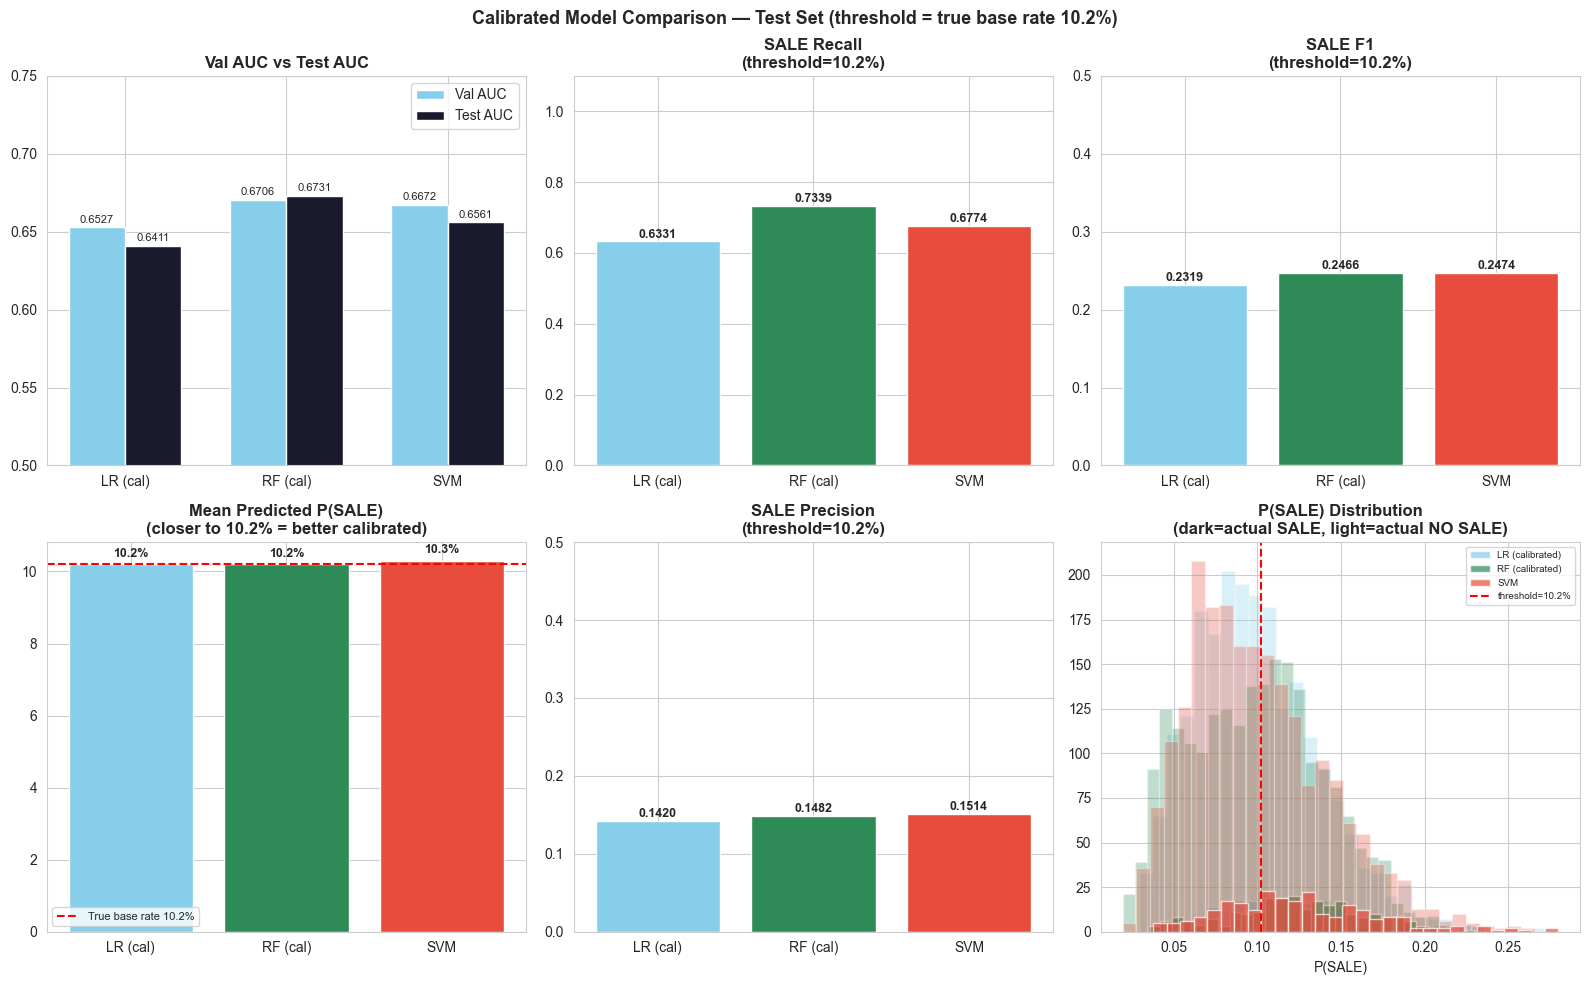

In [32]:
# ===== 校准后三模型完整对比（阈值=10.2%）=====

def predict_with_threshold(model, X, threshold=0.102):
    proba = model.predict_proba(X)[:, 1]
    return (proba >= threshold).astype(int)

models_final = {
    'LR (calibrated)': cal_lr,
    'RF (calibrated)': cal_rf,
    'SVM'            : pipe_svm_best
}

rows = []
for name, model in models_final.items():
    pred      = predict_with_threshold(model, X_test_sel)
    proba     = model.predict_proba(X_test_sel)[:, 1]
    proba_val = model.predict_proba(X_val_sel)[:, 1]
    report    = classification_report(y_test, pred,
                                      target_names=['NO SALE','SALE'],
                                      output_dict=True, zero_division=0)
    rows.append({
        'Model'         : name,
        'Val AUC'       : round(roc_auc_score(y_val,  proba_val), 4),
        'Test AUC'      : round(roc_auc_score(y_test, proba),     4),
        'SALE Recall'   : round(report['SALE']['recall'],          4),
        'SALE Precision': round(report['SALE']['precision'],       4),
        'SALE F1'       : round(report['SALE']['f1-score'],        4),
        'Mean P(SALE)'  : round(proba.mean() * 100, 1),
        'proba'         : proba
    })

compare_df = pd.DataFrame(rows).set_index('Model')
print("===== Calibrated Model Comparison — Test Set (threshold=10.2%) =====")
print(compare_df.drop(columns='proba').to_string())

# ===== 可视化 =====
colors      = ['#87CEEB', '#2E8B57', '#E74C3C']
short_names = ['LR (cal)', 'RF (cal)', 'SVM']
fig, axes   = plt.subplots(2, 3, figsize=(16, 10))

# 图1: Val AUC vs Test AUC
x, w = np.arange(3), 0.35
axes[0,0].bar(x-w/2, compare_df['Val AUC'],  width=w, color='#87CEEB', label='Val AUC')
axes[0,0].bar(x+w/2, compare_df['Test AUC'], width=w, color='#1a1a2e', label='Test AUC')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(short_names)
axes[0,0].set_ylim(0.5, 0.75)
axes[0,0].set_title('Val AUC vs Test AUC', fontweight='bold')
axes[0,0].legend()
for i, row in enumerate(rows):
    axes[0,0].text(i-w/2, row['Val AUC']  + 0.003, f"{row['Val AUC']:.4f}",
                   ha='center', fontsize=8)
    axes[0,0].text(i+w/2, row['Test AUC'] + 0.003, f"{row['Test AUC']:.4f}",
                   ha='center', fontsize=8)

# 图2: SALE Recall
for i, (val, c) in enumerate(zip(compare_df['SALE Recall'], colors)):
    axes[0,1].bar(short_names[i], val, color=c, edgecolor='white')
    axes[0,1].text(i, val+0.01, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_ylim(0, 1.1)
axes[0,1].set_title('SALE Recall\n(threshold=10.2%)', fontweight='bold')

# 图3: SALE F1
for i, (val, c) in enumerate(zip(compare_df['SALE F1'], colors)):
    axes[0,2].bar(short_names[i], val, color=c, edgecolor='white')
    axes[0,2].text(i, val+0.005, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0,2].set_ylim(0, 0.5)
axes[0,2].set_title('SALE F1\n(threshold=10.2%)', fontweight='bold')

# 图4: Mean P(SALE) vs True Base Rate
for i, (val, c) in enumerate(zip(compare_df['Mean P(SALE)'], colors)):
    axes[1,0].bar(short_names[i], val, color=c, edgecolor='white')
    axes[1,0].text(i, val+0.2, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1,0].axhline(10.2, color='red', linestyle='--', linewidth=1.5,
                  label='True base rate 10.2%')
axes[1,0].set_title('Mean Predicted P(SALE)\n(closer to 10.2% = better calibrated)',
                    fontweight='bold')
axes[1,0].legend(fontsize=8)

# 图5: SALE Precision
for i, (val, c) in enumerate(zip(compare_df['SALE Precision'], colors)):
    axes[1,1].bar(short_names[i], val, color=c, edgecolor='white')
    axes[1,1].text(i, val+0.005, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1,1].set_ylim(0, 0.5)
axes[1,1].set_title('SALE Precision\n(threshold=10.2%)', fontweight='bold')

# 图6: P(SALE) 分布
sale_mask   = y_test == 1
nosale_mask = y_test == 0
for row, color in zip(rows, colors):
    axes[1,2].hist(row['proba'][nosale_mask], bins=30, alpha=0.3, color=color)
    axes[1,2].hist(row['proba'][sale_mask],   bins=30, alpha=0.7, color=color,
                   label=row['Model'])
axes[1,2].axvline(0.102, color='red',    linestyle='--', linewidth=1.5,
                  label='threshold=10.2%')
axes[1,2].set_xlabel('P(SALE)')
axes[1,2].set_title('P(SALE) Distribution\n(dark=actual SALE, light=actual NO SALE)',
                    fontweight='bold')
axes[1,2].legend(fontsize=7)

plt.suptitle('Calibrated Model Comparison — Test Set (threshold = true base rate 10.2%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### 三个公司的 Basecase

Lead                   RF(cal) P(SALE)      Verdict
Alberta Wood                     11.4%   Borderline
DRIP                              4.7%     Unlikely
Healthcare Provider              13.6%   Borderline
Baseline win rate.....           10.2%


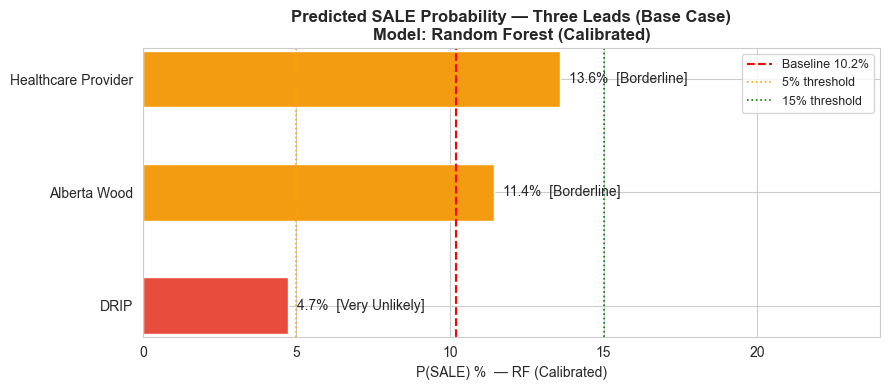

In [33]:
# ===== Three Leads — Base Case (cal_rf) =====
cat_defaults = {c: X_train_sel[c].mode()[0] for c in cat_sel}
num_defaults = {c: X_train_sel[c].median()   for c in num_sel}

leads_known = {
    'Alberta Wood': {
        'product_type': 'DSC', 'geography': 'ROW',
        'industry_type': 'traditional_manufacturing',
        'industry_position': 'leader', 'deal_size': 40000,
    },
    'DRIP': {
        'product_type': 'CRM', 'geography': 'Europe',
        'industry_type': 'traditional_manufacturing',
        'industry_position': 'follower',
        'account_team_rank': 'low', 'procurement_locus': 'procurement_driven',
    },
    'Healthcare Provider': {
        'product_type': 'DSC', 'geography': 'ROW',
        'industry_type': 'healthcare',
        'account_team_rank': 'high', 'procurement_locus': 'LOB_driven',
        'deal_size': 20000,
    }
}

print("=" * 55)
print(f"{'Lead':<22} {'RF(cal) P(SALE)':>15} {'Verdict':>12}")
print("=" * 55)

results_rf = {}
for company, known in leads_known.items():
    row     = {**cat_defaults, **num_defaults, **known}
    df_lead = pd.DataFrame([row])[selected_original_cols]
    p       = cal_rf.predict_proba(df_lead)[0, 1]
    results_rf[company] = p
    v = "Promising" if p > 0.15 else "Borderline" if p > 0.10 else "Unlikely"
    print(f"{company:<22} {p*100:>14.1f}% {v:>12}")

print("=" * 55)
print(f"{'Baseline win rate':.<22} {'10.2%':>15}")

# 图
def prob_color(p):
    if p > 0.15:   return '#2E8B57'
    elif p > 0.10: return '#F39C12'
    elif p > 0.05: return '#E67E22'
    else:          return '#E74C3C'

sorted_co = sorted(leads_known.keys(), key=lambda c: results_rf[c])
fig, ax   = plt.subplots(figsize=(9, 4))
bars = ax.barh(sorted_co, [results_rf[c]*100 for c in sorted_co],
               color=[prob_color(results_rf[c]) for c in sorted_co],
               edgecolor='white', height=0.5)
ax.axvline(10.2, color='red',    linestyle='--', lw=1.5, label='Baseline 10.2%')
ax.axvline(5,    color='orange', linestyle=':',  lw=1.2, label='5% threshold')
ax.axvline(15,   color='green',  linestyle=':',  lw=1.2, label='15% threshold')
for bar, c in zip(bars, sorted_co):
    p = results_rf[c]
    v = "Promising" if p>0.15 else "Borderline" if p>0.10 else "Unlikely" if p>0.05 else "Very Unlikely"
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{p*100:.1f}%  [{v}]", va='center', fontsize=10)
ax.set_xlabel('P(SALE) %  — RF (Calibrated)')
ax.set_xlim(0, 24); ax.margins(y=0.01)
ax.set_title('Predicted SALE Probability — Three Leads (Base Case)\nModel: Random Forest (Calibrated)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


Lead                      RF(cal)  RF Rank      SVM  SVM Rank
Healthcare Provider         13.6%       #1    11.9%        #1
Alberta Wood                11.4%       #2    11.4%        #2
DRIP                         4.7%       #3     5.7%        #3

排名一致: ✅ RF(cal) 与 SVM 排名完全一致


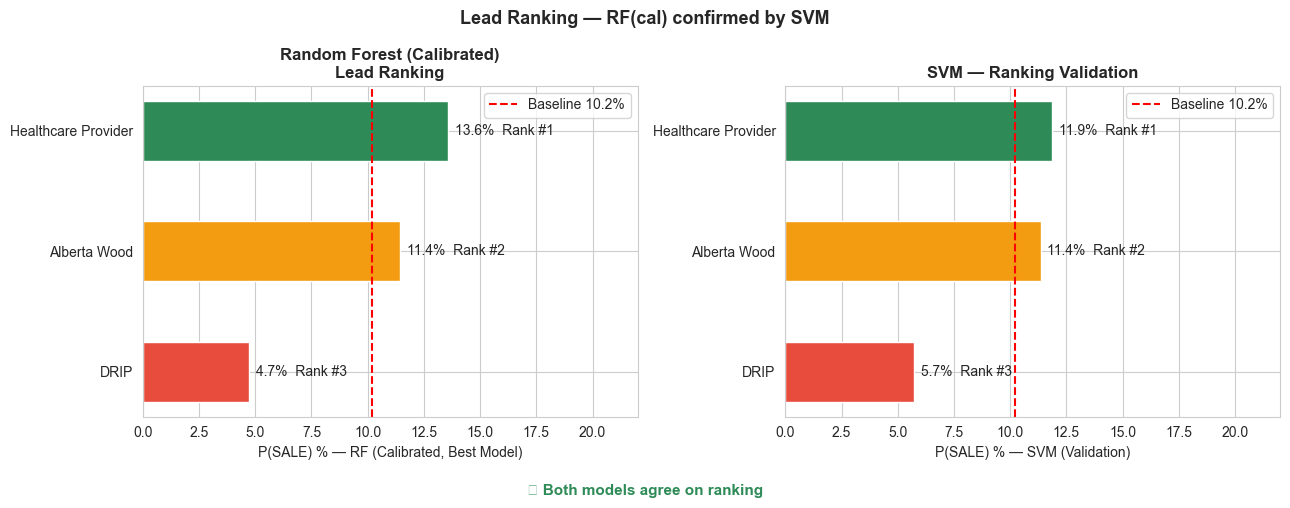

In [34]:
# ===== 排名验证：RF(cal) vs SVM =====
rf_scores  = []
svm_scores = []
companies  = list(leads_known.keys())

for company, known in leads_known.items():
    row     = {**cat_defaults, **num_defaults, **known}
    df_lead = pd.DataFrame([row])[selected_original_cols]
    rf_scores.append(cal_rf.predict_proba(df_lead)[0, 1])
    svm_scores.append(pipe_svm_best.predict_proba(df_lead)[0, 1])

order      = sorted(range(3), key=lambda i: rf_scores[i], reverse=True)
companies  = [companies[i]  for i in order]
rf_scores  = [rf_scores[i]  for i in order]
svm_scores = [svm_scores[i] for i in order]

rf_ranks  = {c: i+1 for i, c in enumerate(companies)}
svm_ranks = {c: i+1 for i, c in enumerate(
    sorted(companies, key=lambda c: svm_scores[companies.index(c)], reverse=True))}

print("=" * 60)
print(f"{'Lead':<22} {'RF(cal)':>10} {'RF Rank':>8} {'SVM':>8} {'SVM Rank':>9}")
print("=" * 60)
for c in companies:
    i = companies.index(c)
    print(f"{c:<22} {rf_scores[i]*100:>9.1f}% {'#'+str(rf_ranks[c]):>8} "
          f"{svm_scores[i]*100:>7.1f}% {'#'+str(svm_ranks[c]):>9}")
print("=" * 60)
match = all(rf_ranks[c] == svm_ranks[c] for c in companies)
print(f"\n排名一致: {'✅ RF(cal) 与 SVM 排名完全一致' if match else '❌ 排名不一致'}")

plot_order = companies[::-1]
colors     = ['#E74C3C', '#F39C12', '#2E8B57']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].barh(plot_order, [rf_scores[companies.index(c)]*100 for c in plot_order],
                    color=colors, edgecolor='white', height=0.5)
axes[0].axvline(10.2, color='red', linestyle='--', lw=1.5, label='Baseline 10.2%')
for bar, c in zip(bars, plot_order):
    val = rf_scores[companies.index(c)]
    axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f"{val*100:.1f}%  Rank #{rf_ranks[c]}", va='center', fontsize=10)
axes[0].set_xlabel('P(SALE) % — RF (Calibrated, Best Model)')
axes[0].set_title('Random Forest (Calibrated)\nLead Ranking', fontweight='bold')
axes[0].set_xlim(0, 22); axes[0].legend()

bars2 = axes[1].barh(plot_order, [svm_scores[companies.index(c)]*100 for c in plot_order],
                     color=colors, edgecolor='white', height=0.5)
axes[1].axvline(10.2, color='red', linestyle='--', lw=1.5, label='Baseline 10.2%')
for bar, c in zip(bars2, plot_order):
    val = svm_scores[companies.index(c)]
    axes[1].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f"{val*100:.1f}%  Rank #{svm_ranks[c]}", va='center', fontsize=10)
axes[1].set_xlabel('P(SALE) % — SVM (Validation)')
axes[1].set_title('SVM — Ranking Validation', fontweight='bold')
axes[1].set_xlim(0, 22); axes[1].legend()

if match:
    fig.text(0.5, 0.01, '✅ Both models agree on ranking',
             ha='center', fontsize=11, fontweight='bold', color='#2E8B57')
plt.suptitle('Lead Ranking — RF(cal) confirmed by SVM', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()


Alberta Wood — 1215 scenarios
  Min:5.3%  Max:20.7%  Mean:12.0%


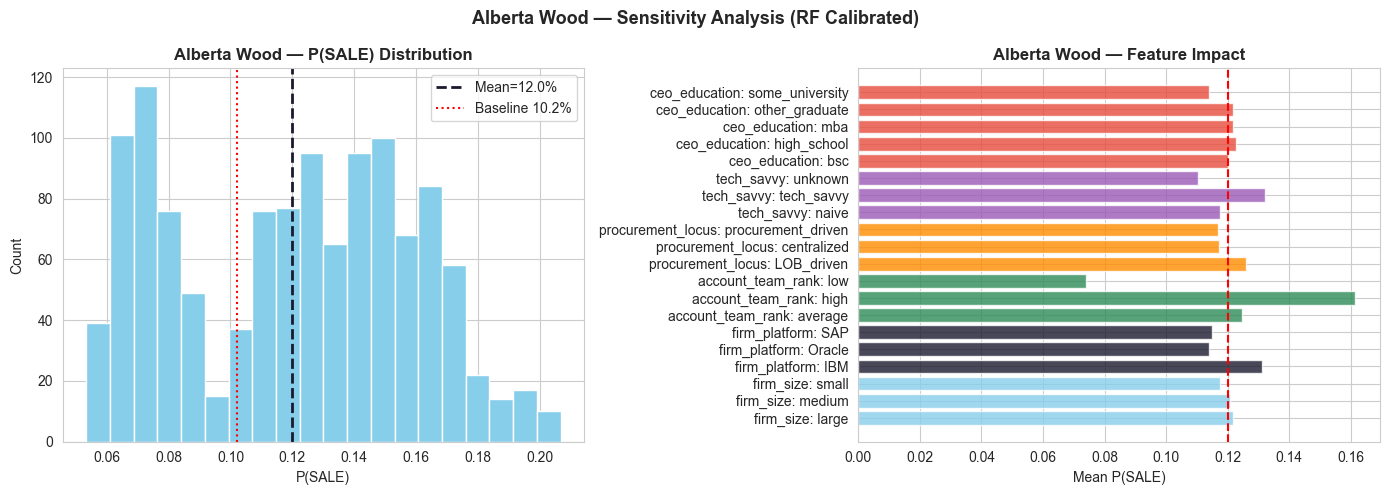

In [35]:
# ===== Alberta Wood — Sensitivity Analysis (cal_rf) =====
aw_known = {
    'product_type': 'DSC', 'geography': 'ROW',
    'industry_type': 'traditional_manufacturing',
    'industry_position': 'leader', 'deal_size': 40000,
}
aw_unknown_cat = {c: sorted(X_train_sel[c].unique().tolist())
                  for c in cat_sel if c not in aw_known}
aw_num_fixed   = {c: X_train_sel[c].median() for c in num_sel if c not in aw_known}

keys   = list(aw_unknown_cat.keys())
combos = list(iproduct(*aw_unknown_cat.values()))
rows   = [{**aw_known, **aw_num_fixed, **dict(zip(keys, c))} for c in combos]
aw_df  = pd.DataFrame(rows)[selected_original_cols]
aw_probs = cal_rf.predict_proba(aw_df)[:, 1]
aw_df['p_sale'] = aw_probs

print(f"Alberta Wood — {len(combos)} scenarios")
print(f"  Min:{aw_probs.min()*100:.1f}%  Max:{aw_probs.max()*100:.1f}%  Mean:{aw_probs.mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(aw_probs, bins=20, color='#87CEEB', edgecolor='white')
axes[0].axvline(aw_probs.mean(), color='#1a1a2e', linestyle='--', lw=2,
                label=f'Mean={aw_probs.mean()*100:.1f}%')
axes[0].axvline(0.102, color='red', linestyle=':', lw=1.5, label='Baseline 10.2%')
axes[0].set_xlabel('P(SALE)'); axes[0].set_ylabel('Count')
axes[0].set_title('Alberta Wood — P(SALE) Distribution', fontweight='bold')
axes[0].legend()

impact = [{'Feature': f, 'Value': v,
           'Mean P(SALE)': aw_df[aw_df[f]==v]['p_sale'].mean()}
          for f, opts in aw_unknown_cat.items() for v in opts]
imp_df     = pd.DataFrame(impact)
colors_map = dict(zip(aw_unknown_cat.keys(),
                      ['#87CEEB','#1a1a2e','#2E8B57','#FF8C00','#9B59B6','#E74C3C']))
for f in aw_unknown_cat:
    sub = imp_df[imp_df['Feature']==f]
    axes[1].barh(sub['Feature']+': '+sub['Value'],
                 sub['Mean P(SALE)'], color=colors_map[f], alpha=0.8)
axes[1].axvline(aw_probs.mean(), color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Mean P(SALE)')
axes[1].set_title('Alberta Wood — Feature Impact', fontweight='bold')
plt.suptitle('Alberta Wood — Sensitivity Analysis (RF Calibrated)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


DRIP — 135 scenarios
  Min:4.3%  Max:7.5%  Mean:5.6%


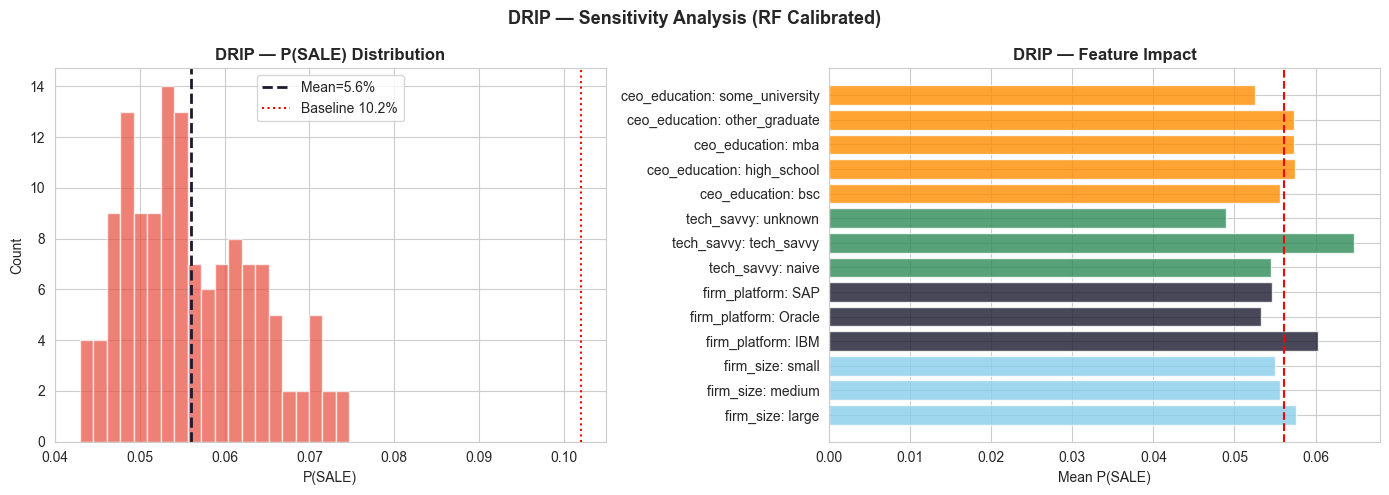

In [36]:
# ===== DRIP — Sensitivity Analysis (cal_rf) =====
drip_known = {
    'product_type': 'CRM', 'geography': 'Europe',
    'industry_type': 'traditional_manufacturing',
    'industry_position': 'follower',
    'account_team_rank': 'low', 'procurement_locus': 'procurement_driven',
}
drip_unknown_cat = {c: sorted(X_train_sel[c].unique().tolist())
                    for c in cat_sel if c not in drip_known}
drip_num_fixed   = {c: X_train_sel[c].median() for c in num_sel}

keys   = list(drip_unknown_cat.keys())
combos = list(iproduct(*drip_unknown_cat.values()))
rows   = [{**drip_known, **drip_num_fixed, **dict(zip(keys, c))} for c in combos]
drip_df    = pd.DataFrame(rows)[selected_original_cols]
drip_probs = cal_rf.predict_proba(drip_df)[:, 1]
drip_df['p_sale'] = drip_probs

print(f"DRIP — {len(combos)} scenarios")
print(f"  Min:{drip_probs.min()*100:.1f}%  Max:{drip_probs.max()*100:.1f}%  Mean:{drip_probs.mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(drip_probs, bins=20, color='#E74C3C', edgecolor='white', alpha=0.7)
axes[0].axvline(drip_probs.mean(), color='#1a1a2e', linestyle='--', lw=2,
                label=f'Mean={drip_probs.mean()*100:.1f}%')
axes[0].axvline(0.102, color='red', linestyle=':', lw=1.5, label='Baseline 10.2%')
axes[0].set_xlabel('P(SALE)'); axes[0].set_ylabel('Count')
axes[0].set_title('DRIP — P(SALE) Distribution', fontweight='bold')
axes[0].legend()

impact = [{'Feature': f, 'Value': v,
           'Mean P(SALE)': drip_df[drip_df[f]==v]['p_sale'].mean()}
          for f, opts in drip_unknown_cat.items() for v in opts]
imp_df     = pd.DataFrame(impact)
colors_map = dict(zip(drip_unknown_cat.keys(),
                      ['#87CEEB','#1a1a2e','#2E8B57','#FF8C00']))
for f in drip_unknown_cat:
    sub = imp_df[imp_df['Feature']==f]
    axes[1].barh(sub['Feature']+': '+sub['Value'],
                 sub['Mean P(SALE)'], color=colors_map[f], alpha=0.8)
axes[1].axvline(drip_probs.mean(), color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Mean P(SALE)')
axes[1].set_title('DRIP — Feature Impact', fontweight='bold')
plt.suptitle('DRIP — Sensitivity Analysis (RF Calibrated)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


Healthcare Provider — 270 scenarios
  Min:11.5%  Max:18.1%  Mean:14.5%


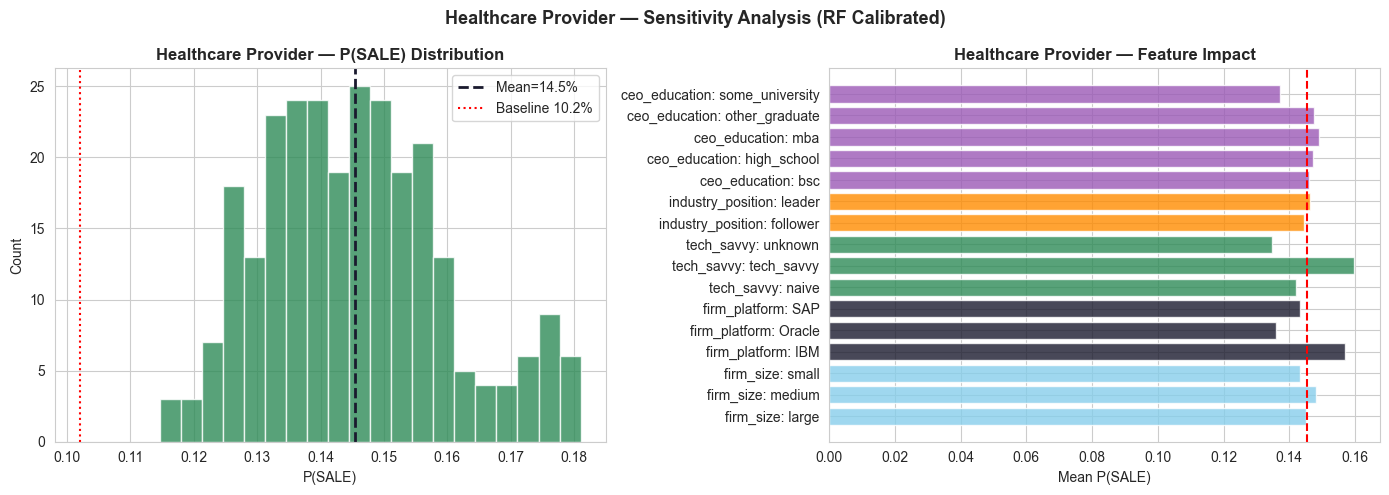

In [37]:
# ===== Healthcare Provider — Sensitivity Analysis (cal_rf) =====
hc_known = {
    'product_type': 'DSC', 'geography': 'ROW',
    'industry_type': 'healthcare',
    'account_team_rank': 'high', 'procurement_locus': 'LOB_driven',
    'deal_size': 20000,
}
hc_unknown_cat = {c: sorted(X_train_sel[c].unique().tolist())
                  for c in cat_sel if c not in hc_known}
hc_num_fixed   = {c: X_train_sel[c].median() for c in num_sel if c not in hc_known}

keys   = list(hc_unknown_cat.keys())
combos = list(iproduct(*hc_unknown_cat.values()))
rows   = [{**hc_known, **hc_num_fixed, **dict(zip(keys, c))} for c in combos]
hc_df    = pd.DataFrame(rows)[selected_original_cols]
hc_probs = cal_rf.predict_proba(hc_df)[:, 1]
hc_df['p_sale'] = hc_probs

print(f"Healthcare Provider — {len(combos)} scenarios")
print(f"  Min:{hc_probs.min()*100:.1f}%  Max:{hc_probs.max()*100:.1f}%  Mean:{hc_probs.mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(hc_probs, bins=20, color='#2E8B57', edgecolor='white', alpha=0.8)
axes[0].axvline(hc_probs.mean(), color='#1a1a2e', linestyle='--', lw=2,
                label=f'Mean={hc_probs.mean()*100:.1f}%')
axes[0].axvline(0.102, color='red', linestyle=':', lw=1.5, label='Baseline 10.2%')
axes[0].set_xlabel('P(SALE)'); axes[0].set_ylabel('Count')
axes[0].set_title('Healthcare Provider — P(SALE) Distribution', fontweight='bold')
axes[0].legend()

impact = [{'Feature': f, 'Value': v,
           'Mean P(SALE)': hc_df[hc_df[f]==v]['p_sale'].mean()}
          for f, opts in hc_unknown_cat.items() for v in opts]
imp_df     = pd.DataFrame(impact)
colors_map = dict(zip(hc_unknown_cat.keys(),
                      ['#87CEEB','#1a1a2e','#2E8B57','#FF8C00','#9B59B6']))
for f in hc_unknown_cat:
    sub = imp_df[imp_df['Feature']==f]
    axes[1].barh(sub['Feature']+': '+sub['Value'],
                 sub['Mean P(SALE)'], color=colors_map[f], alpha=0.8)
axes[1].axvline(hc_probs.mean(), color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Mean P(SALE)')
axes[1].set_title('Healthcare Provider — Feature Impact', fontweight='bold')
plt.suptitle('Healthcare Provider — Sensitivity Analysis (RF Calibrated)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


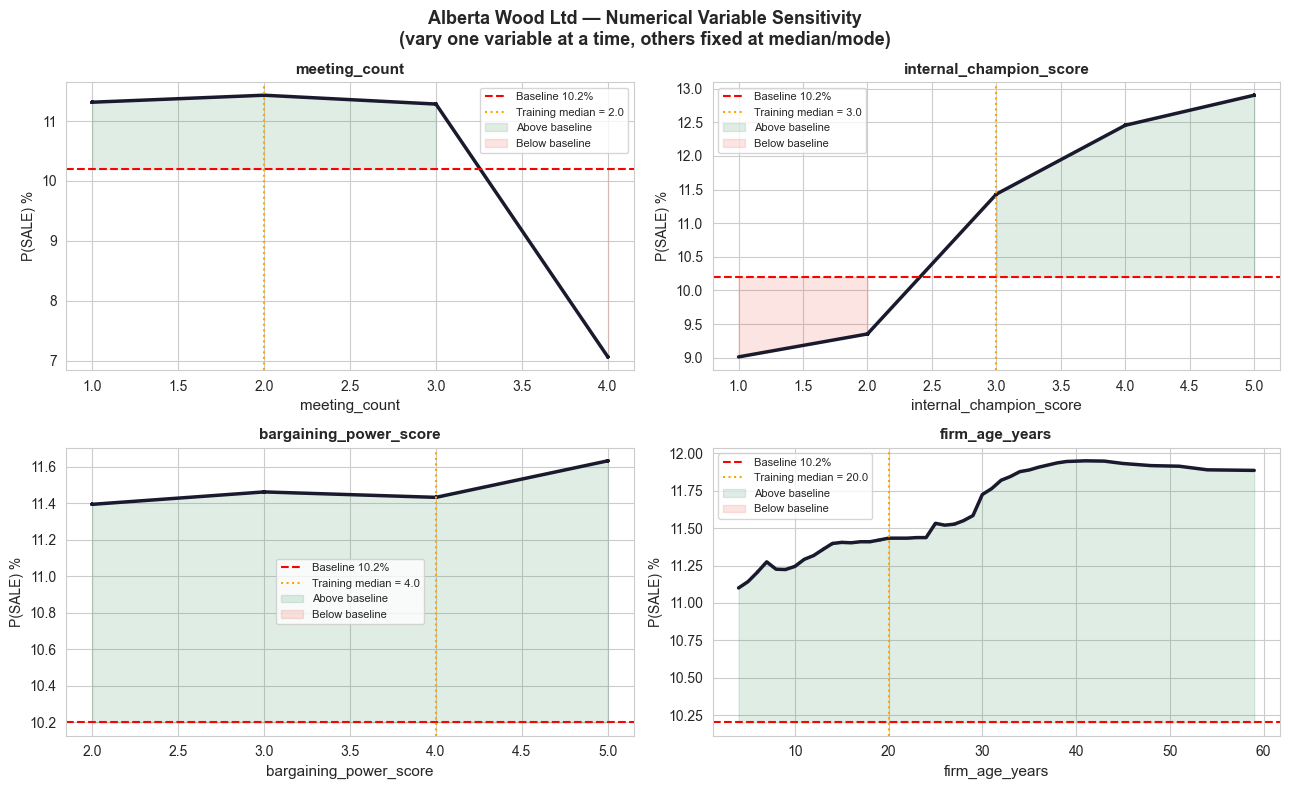

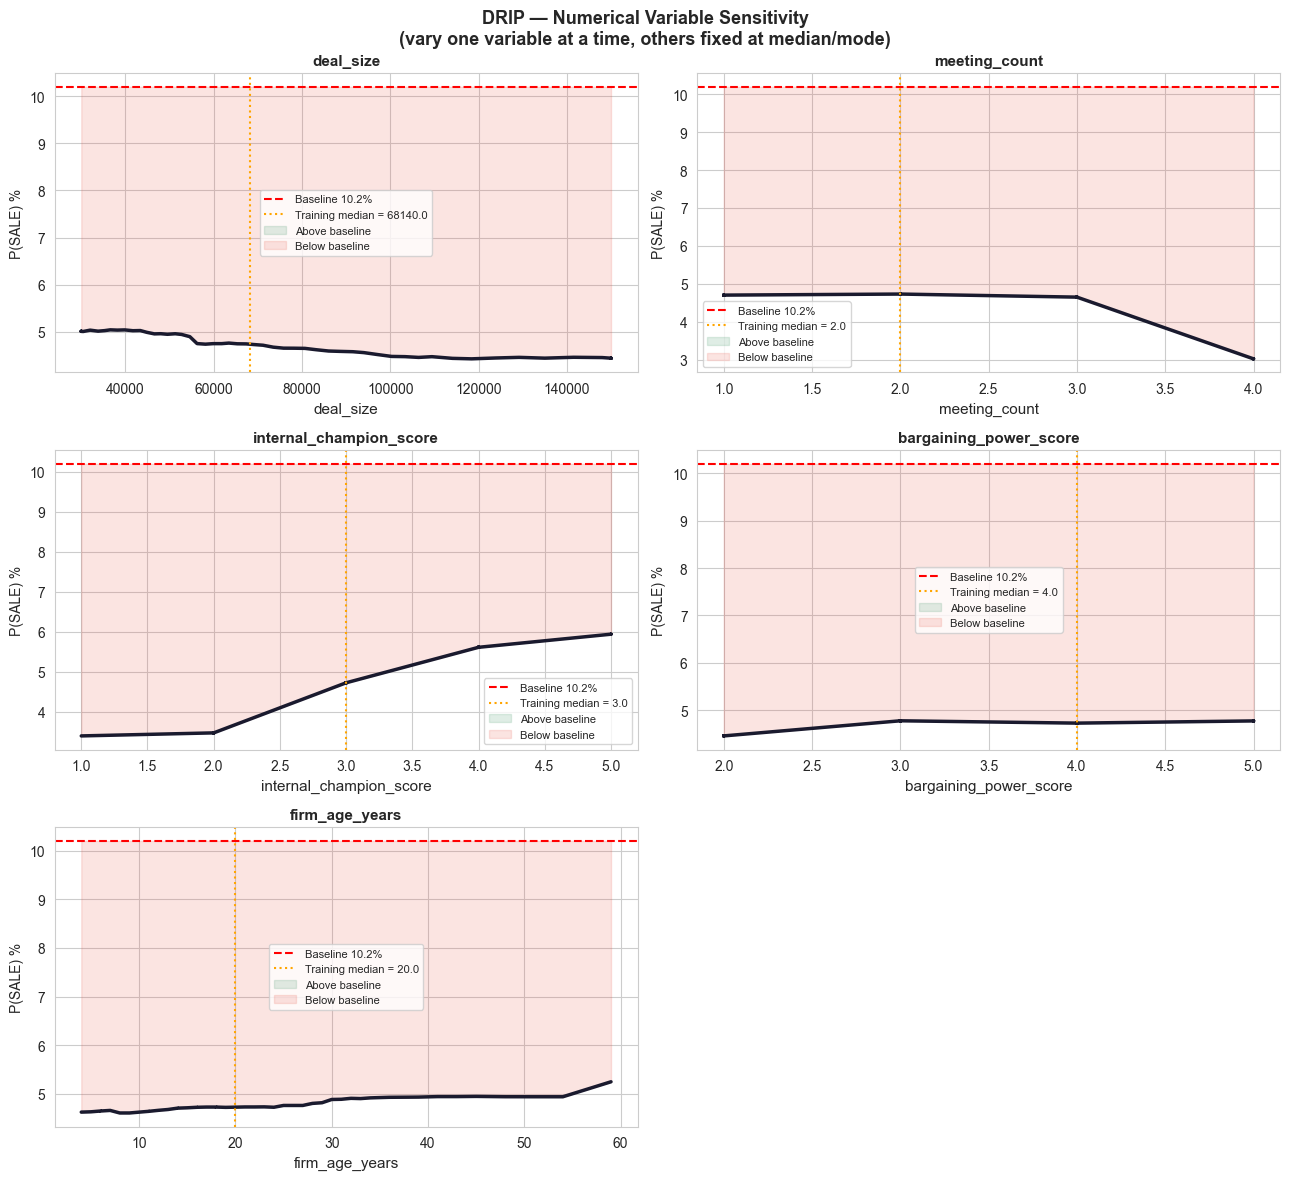

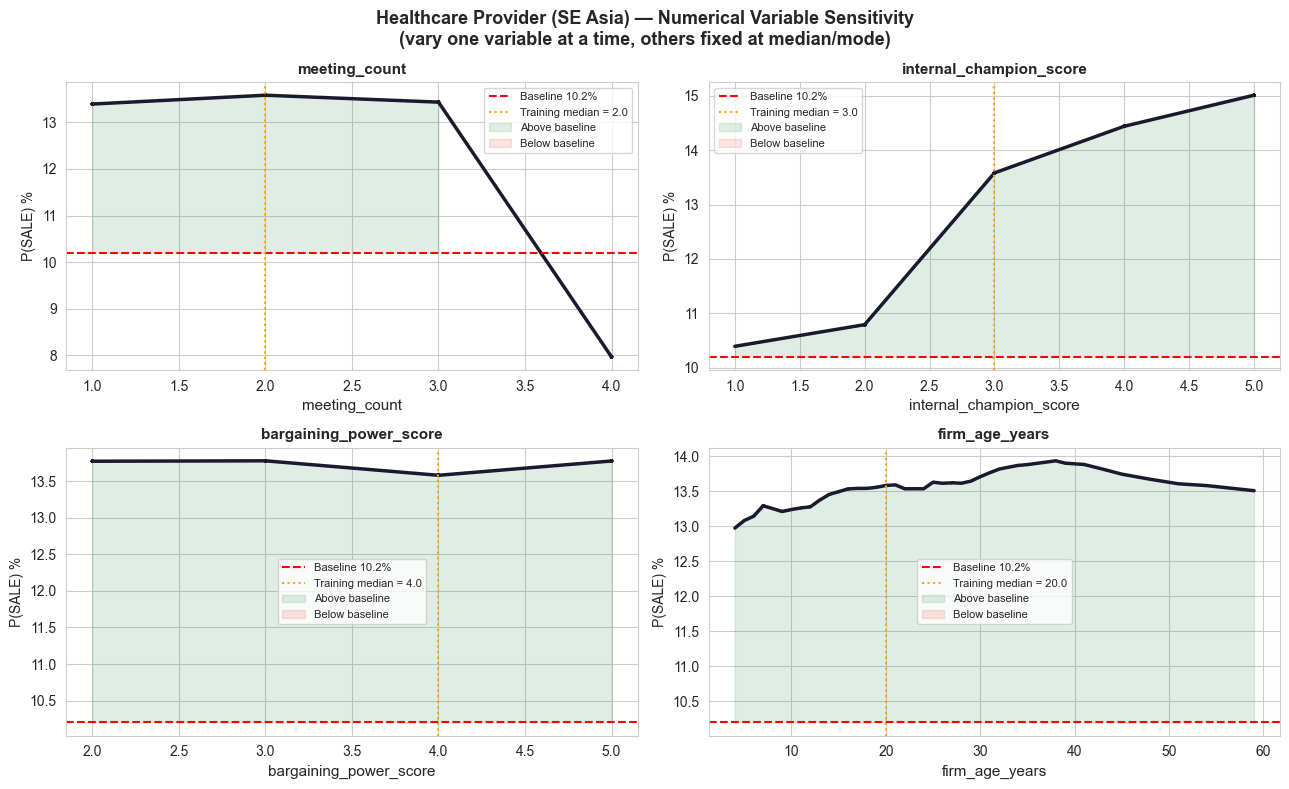

In [38]:
# ===== Numerical Variable Sensitivity (Partial Dependence Style) =====
# 每次只变动一个数值变量（P5–P95范围），其他变量固定在 median/mode

def plot_numerical_sensitivity(pipe, known, cat_defaults, num_defaults,
                                unknown_num_cols, selected_cols,
                                company_name, n_points=60, baseline=0.102):
    if not unknown_num_cols:
        print(f"{company_name}: No unknown numerical variables.")
        return

    ncols = 2
    nrows = (len(unknown_num_cols) + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, var in enumerate(unknown_num_cols):
        # 从训练集取该变量的P5到P95范围
        x_range = np.percentile(X_train_sel[var], np.linspace(5, 95, n_points))

        probs = []
        for val in x_range:
            row = {**cat_defaults, **num_defaults, **known, var: val}
            prob = pipe.predict_proba(pd.DataFrame([row])[selected_cols])[0, 1] * 100
            probs.append(prob)

        ax = axes[i]
        probs_arr = np.array(probs)

        ax.plot(x_range, probs_arr, color='#1a1a2e', linewidth=2.5)
        ax.axhline(baseline * 100, color='red', linestyle='--', linewidth=1.5,
                   label=f'Baseline {baseline*100:.1f}%')

        # 标记训练集中位数位置
        med_val = num_defaults.get(var, np.median(x_range))
        ax.axvline(med_val, color='orange', linestyle=':', linewidth=1.5,
                   label=f'Training median = {med_val:.1f}')

        # 高于/低于baseline着色
        ax.fill_between(x_range, baseline * 100, probs_arr,
                        where=probs_arr >= baseline * 100,
                        alpha=0.15, color='#2E8B57', label='Above baseline')
        ax.fill_between(x_range, baseline * 100, probs_arr,
                        where=probs_arr < baseline * 100,
                        alpha=0.15, color='#E74C3C', label='Below baseline')

        ax.set_xlabel(var, fontsize=11)
        ax.set_ylabel('P(SALE) %', fontsize=10)
        ax.set_title(var, fontweight='bold', fontsize=11)
        ax.legend(fontsize=8)

    for j in range(len(unknown_num_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'{company_name} — Numerical Variable Sensitivity\n'
                 f'(vary one variable at a time, others fixed at median/mode)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ---- Alberta Wood ----
aw_unknown_num  = [c for c in num_sel if c not in aw_known]
aw_unknown_cat2 = [c for c in cat_sel if c not in aw_known]
aw_cat_def2 = {c: X_train_sel[c].mode()[0] for c in aw_unknown_cat2}
aw_num_def2 = {c: X_train_sel[c].median()  for c in aw_unknown_num}
plot_numerical_sensitivity(cal_rf, aw_known,
                           aw_cat_def2, aw_num_def2,
                           aw_unknown_num, selected_original_cols, 'Alberta Wood Ltd')

# ---- DRIP ----
drip_unknown_num  = [c for c in num_sel if c not in drip_known]
drip_unknown_cat2 = [c for c in cat_sel if c not in drip_known]
drip_cat_def2 = {c: X_train_sel[c].mode()[0] for c in drip_unknown_cat2}
drip_num_def2 = {c: X_train_sel[c].median()  for c in drip_unknown_num}
plot_numerical_sensitivity(cal_rf, drip_known,
                           drip_cat_def2, drip_num_def2,
                           drip_unknown_num, selected_original_cols, 'DRIP')

# ---- Healthcare Provider ----
hc_unknown_num  = [c for c in num_sel if c not in hc_known]
hc_unknown_cat2 = [c for c in cat_sel if c not in hc_known]
hc_cat_def2 = {c: X_train_sel[c].mode()[0] for c in hc_unknown_cat2}
hc_num_def2 = {c: X_train_sel[c].median()  for c in hc_unknown_num}
plot_numerical_sensitivity(cal_rf, hc_known,
                           hc_cat_def2, hc_num_def2,
                           hc_unknown_num, selected_original_cols, 'Healthcare Provider (SE Asia)')



Alberta Wood Ltd — Monte Carlo (5,000 simulations)
  P10=5.7%  P25=8.0%  Median=11.3%  P75=13.6%  P90=16.0%
  Mean=11.0%  Std=3.84%
  Prob(beat baseline 10.2%) = 59% of scenarios


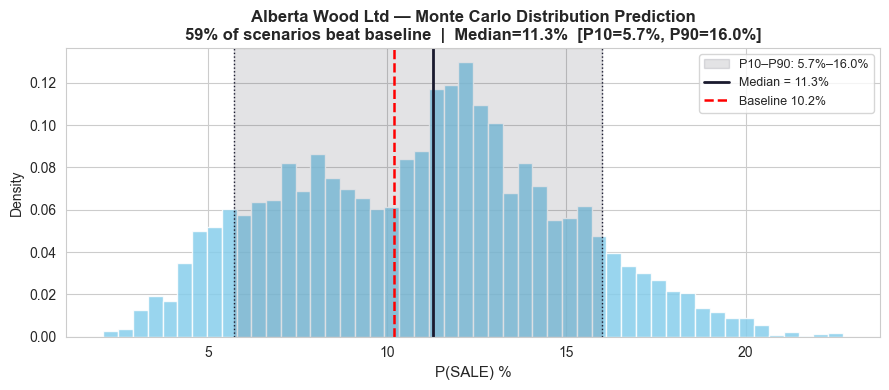


DRIP — Monte Carlo (5,000 simulations)
  P10=3.3%  P25=4.0%  Median=5.1%  P75=6.0%  P90=6.9%
  Mean=5.1%  Std=1.41%
  Prob(beat baseline 10.2%) = 0% of scenarios


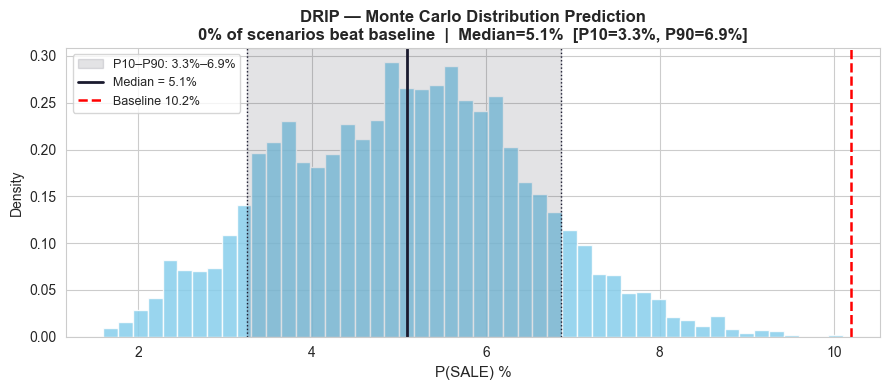


Healthcare Provider (SE Asia) — Monte Carlo (5,000 simulations)
  P10=8.1%  P25=10.9%  Median=13.4%  P75=14.9%  P90=16.1%
  Mean=12.7%  Std=3.13%
  Prob(beat baseline 10.2%) = 81% of scenarios


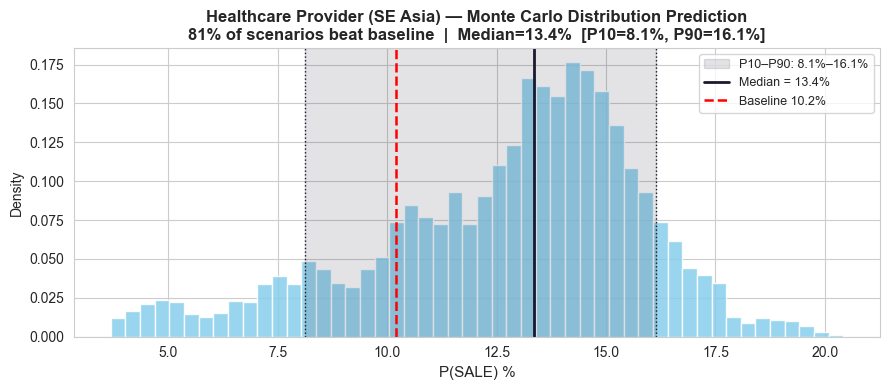

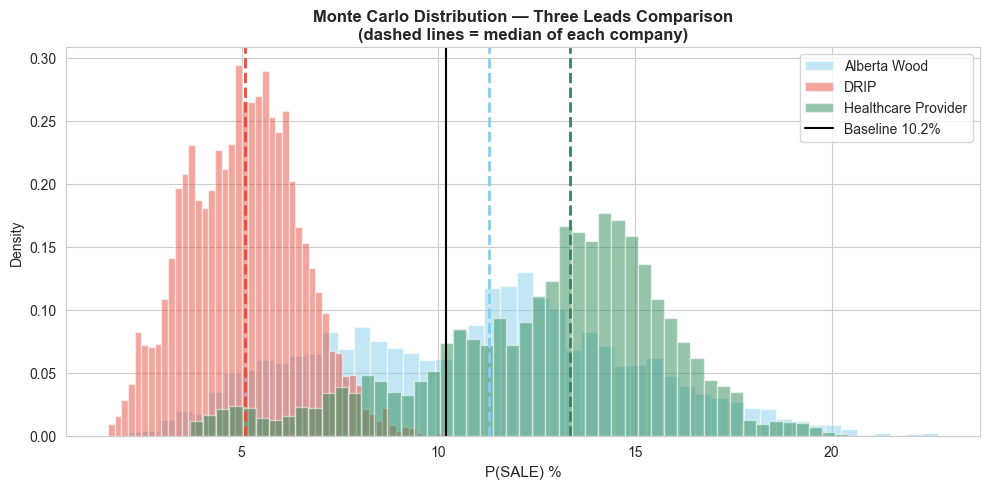

In [39]:
# ===== Monte Carlo Distribution Prediction =====
# 未知变量从训练集实际分布中随机抽样（不是固定在median）
# 运行5000次模拟，得到P(SALE)的分布

def monte_carlo_prediction(pipe, known, unknown_cat_cols, unknown_num_cols,
                           X_train, selected_cols,
                           company_name, n_sim=5000, baseline=0.102):
    np.random.seed(42)
    rows = []

    for _ in range(n_sim):
        row = {}
        # 按训练集实际频率比例抽取类别变量
        for col in unknown_cat_cols:
            freq = X_train[col].value_counts(normalize=True)
            row[col] = np.random.choice(freq.index, p=freq.values)
        # 从训练集经验分布中抽取数值变量
        for col in unknown_num_cols:
            row[col] = X_train[col].sample(1).values[0]
        row.update(known)
        rows.append(row)

    df_mc = pd.DataFrame(rows)[selected_cols]
    probs = pipe.predict_proba(df_mc)[:, 1] * 100

    p10, p25, p50, p75, p90 = np.percentile(probs, [10, 25, 50, 75, 90])
    prob_above = (probs > baseline * 100).mean() * 100

    print(f"\n{'='*55}")
    print(f"{company_name} — Monte Carlo ({n_sim:,} simulations)")
    print(f"  P10={p10:.1f}%  P25={p25:.1f}%  Median={p50:.1f}%  "
          f"P75={p75:.1f}%  P90={p90:.1f}%")
    print(f"  Mean={probs.mean():.1f}%  Std={probs.std():.2f}%")
    print(f"  Prob(beat baseline {baseline*100:.1f}%) = {prob_above:.0f}% of scenarios")
    print(f"{'='*55}")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(probs, bins=50, color='#87CEEB', edgecolor='white',
            density=True, alpha=0.85)

    # P10–P90区间阴影
    ax.axvspan(p10, p90, alpha=0.12, color='#1a1a2e', label=f'P10–P90: {p10:.1f}%–{p90:.1f}%')
    ax.axvline(p50,           color='#1a1a2e', linewidth=2,   linestyle='-',
               label=f'Median = {p50:.1f}%')
    ax.axvline(p10,           color='#1a1a2e', linewidth=1,   linestyle=':')
    ax.axvline(p90,           color='#1a1a2e', linewidth=1,   linestyle=':')
    ax.axvline(baseline * 100, color='red',    linewidth=1.8, linestyle='--',
               label=f'Baseline {baseline*100:.1f}%')

    ax.set_xlabel('P(SALE) %', fontsize=11)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(
        f'{company_name} — Monte Carlo Distribution Prediction\n'
        f'{prob_above:.0f}% of scenarios beat baseline  |  '
        f'Median={p50:.1f}%  [P10={p10:.1f}%, P90={p90:.1f}%]',
        fontweight='bold', fontsize=12
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    return probs


# ---- Alberta Wood ----
aw_mc = monte_carlo_prediction(
    cal_rf, aw_known,
    [c for c in cat_sel if c not in aw_known],
    [c for c in num_sel if c not in aw_known],
    X_train_sel, selected_original_cols, 'Alberta Wood Ltd'
)

# ---- DRIP ----
drip_mc = monte_carlo_prediction(
    cal_rf, drip_known,
    [c for c in cat_sel if c not in drip_known],
    [c for c in num_sel if c not in drip_known],
    X_train_sel, selected_original_cols, 'DRIP'
)

# ---- Healthcare Provider ----
hc_mc = monte_carlo_prediction(
    cal_rf, hc_known,
    [c for c in cat_sel if c not in hc_known],
    [c for c in num_sel if c not in hc_known],
    X_train_sel, selected_original_cols, 'Healthcare Provider (SE Asia)'
)

# ---- 三个公司对比总览 ----
fig, ax = plt.subplots(figsize=(10, 5))
colors_mc = ['#87CEEB', '#E74C3C', '#2E8B57']
labels    = ['Alberta Wood', 'DRIP', 'Healthcare Provider']

for probs, color, label in zip([aw_mc, drip_mc, hc_mc], colors_mc, labels):
    ax.hist(probs, bins=50, density=True, alpha=0.5, color=color, label=label)
    ax.axvline(np.median(probs), color=color, linewidth=2, linestyle='--')

ax.axvline(10.2, color='black', linewidth=1.5, linestyle='-', label='Baseline 10.2%')
ax.set_xlabel('P(SALE) %', fontsize=11)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Monte Carlo Distribution — Three Leads Comparison\n'
             '(dashed lines = median of each company)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
